Cervical Cancer Risk Prediction
Mid-Term Presentation



**Goal:** Predict whether a patient has cervical cancer based on her medical history, using machine learning.

**Dataset:** UCI Cervical Cancer Risk Factors — 858 patients, 36 features.

**Target variable:** Biopsy (0 = Negative, 1 = Positive)


In [1]:
# Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.linear_model import Lasso, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)


SECTION 1 — Data Preparation


### 1.1 — Load the Dataset
The dataset uses ? to represent missing values. We tell pandas to treat them as NaN (Not a Number) so we can handle them properly.

In [2]:
# Upload risk_factors_cervical_cancer.csv using the folder icon on the left
data = pd.read_csv('risk_factors_cervical_cancer.csv', na_values='?')

print(f'Dataset shape: {data.shape[0]} patients × {data.shape[1]} features')
print()
data.head()

Dataset shape: 858 patients × 36 features



,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
2,34,1.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,NaN,NaN,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0


### 1.2 — Check Missing Values
Before cleaning, we need to see exactly how many values are missing in each column and what percentage that represents.

In [3]:
missing_count = data.isnull().sum()
missing_pct   = (missing_count / len(data) * 100).round(1)

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_pct
}).sort_values('Missing Count', ascending=False)

# Only show columns that actually have missing values
print('Columns with missing values:')
print(missing_df[missing_df['Missing Count'] > 0].to_string())
print(f'\nTotal missing values in the dataset: {missing_count.sum()}')

Columns with missing values:
                                    Missing Count  Missing %
STDs: Time since first diagnosis              787       91.7
STDs: Time since last diagnosis               787       91.7
IUD                                           117       13.6
IUD (years)                                   117       13.6
Hormonal Contraceptives                       108       12.6
Hormonal Contraceptives (years)               108       12.6
STDs:HPV                                      105       12.2
STDs:AIDS                                     105       12.2
STDs:Hepatitis B                              105       12.2
STDs:HIV                                      105       12.2
STDs                                          105       12.2
STDs:cervical condylomatosis                  105       12.2
STDs:vulvo-perineal condylomatosis            105       12.2
STDs:syphilis                                 105       12.2
STDs:pelvic inflammatory disease              105       

### 1.3 — Drop Columns with More Than 90% Missing

Two columns — **'STDs: Time since first diagnosis'** and **'STDs: Time since last diagnosis'** — are missing for **787 out of 858 patients (91.7%)**. These columns are useless; we cannot impute that much data reliably, so we drop them entirely.

In [4]:
threshold = 0.9 * len(data)
cols_to_drop = data.columns[data.isnull().sum() > threshold]

print('Columns dropped (>90% missing):')
for col in cols_to_drop:
    pct = data[col].isnull().sum() / len(data) * 100
    print(f'  - "{col}"  →  {pct:.1f}% missing  →  DROPPED')

data = data.drop(columns=cols_to_drop)
print(f'\nShape after dropping: {data.shape}')

Columns dropped (>90% missing):
  - "STDs: Time since first diagnosis"  →  91.7% missing  →  DROPPED
  - "STDs: Time since last diagnosis"  →  91.7% missing  →  DROPPED

Shape after dropping: (858, 34)


### 1.4 — Fill Remaining Missing Values with the Median

For all other missing values, we fill them with the **median** of each column.

**Why median and not mean?**
Medical data is often skewed — for example, most patients have 0 STDs, but a few patients have many. The mean gets pulled upward by those outliers, giving an unrealistic value. The median always represents the typical patient.

In [5]:
# Show which columns still have missing values and what their median is
still_missing = data.isnull().sum()
still_missing = still_missing[still_missing > 0]

print('Columns filled with median imputation:')
for col, count in still_missing.items():
    median_val = data[col].median()
    print(f'  .  "{col}"  →  {count} missing  →  filled with median = {median_val}')

data = data.fillna(data.median())
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data = data.fillna(data.median())

print(f'\nMissing values remaining: {data.isnull().sum().sum()}')
print(f'Final clean dataset: {data.shape[0]} patients × {data.shape[1]} features')

Columns filled with median imputation:
  .  "Number of sexual partners"  →  26 missing  →  filled with median = 2.0
  .  "First sexual intercourse"  →  7 missing  →  filled with median = 17.0
  .  "Num of pregnancies"  →  56 missing  →  filled with median = 2.0
  .  "Smokes"  →  13 missing  →  filled with median = 0.0
  .  "Smokes (years)"  →  13 missing  →  filled with median = 0.0
  .  "Smokes (packs/year)"  →  13 missing  →  filled with median = 0.0
  .  "Hormonal Contraceptives"  →  108 missing  →  filled with median = 1.0
  .  "Hormonal Contraceptives (years)"  →  108 missing  →  filled with median = 0.5
  .  "IUD"  →  117 missing  →  filled with median = 0.0
  .  "IUD (years)"  →  117 missing  →  filled with median = 0.0
  .  "STDs"  →  105 missing  →  filled with median = 0.0
  .  "STDs (number)"  →  105 missing  →  filled with median = 0.0
  .  "STDs:condylomatosis"  →  105 missing  →  filled with median = 0.0
  .  "STDs:cervical condylomatosis"  →  105 missing  →  filled with 

### 1.5 — Statistical Summary
A quick look at the key statistics of each feature.

In [6]:
data.describe().round(2)

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs:HPV,STDs: Number of diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
count,858.00,858.00,858.00,858.00,858.00,858.00,858.00,858.00,858.00,858.0,...,858.00,858.00,858.00,858.00,858.00,858.00,858.00,858.00,858.00,858.00
mean,26.82,2.51,17.00,2.26,0.14,1.20,0.45,0.69,2.04,0.1,...,0.00,0.09,0.02,0.01,0.02,0.03,0.04,0.09,0.05,0.06
std,8.50,1.64,2.79,1.40,0.35,4.06,2.21,0.46,3.57,0.3,...,0.05,0.30,0.14,0.10,0.14,0.16,0.20,0.28,0.22,0.25
min,13.00,1.00,10.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,20.00,2.00,15.00,1.00,0.00,0.00,0.00,0.00,0.00,0.0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,25.00,2.00,17.00,2.00,0.00,0.00,0.00,1.00,0.50,0.0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,32.00,3.00,18.00,3.00,0.00,0.00,0.00,1.00,2.00,0.0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
max,84.00,28.00,32.00,11.00,1.00,37.00,37.00,1.00,30.00,1.0,...,1.00,3.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00



# SECTION 2 — Exploratory Data Analysis (EDA)




### 2.1 — Target Variable Distribution (Class Imbalance)

This is the **most important finding** in our EDA.

- **803 patients (93.6%)** → Negative (no cancer)
- **55 patients (6.4%)** → Positive (cancer detected)

This is called **class imbalance**. A model that always predicts "negative" would score **93.6% accuracy while catching zero cancer cases**. That is why accuracy is a misleading metric here — we use **F1 Score** instead, which penalizes models that ignore the minority class.

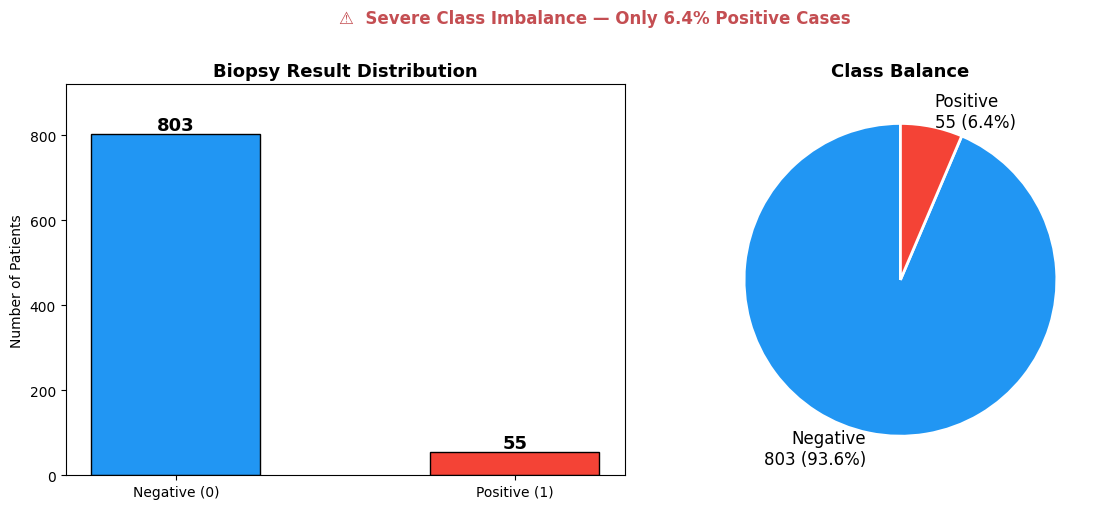

Class distribution:
  Negative (0): 803 patients  (93.6%)
  Positive (1): 55 patients  (6.4%)

 Because of this imbalance, accuracy is NOT our key metric.
   We will use F1 Score, which balances precision and recall.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = data['Biopsy'].value_counts()

# Bar chart
bars = axes[0].bar(['Negative (0)', 'Positive (1)'], counts,
                    color=['#2196F3', '#F44336'], edgecolor='black', width=0.5)
axes[0].set_title('Biopsy Result Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Patients')
axes[0].set_ylim(0, 920)
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 10, str(count),
                 ha='center', fontsize=13, fontweight='bold')

# Pie chart
axes[1].pie(counts,
            labels=[f'Negative\n803 (93.6%)', f'Positive\n55 (6.4%)'],
            colors=['#2196F3', '#F44336'],
            startangle=90, textprops={'fontsize': 12},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Balance', fontsize=13, fontweight='bold')

plt.suptitle('⚠  Severe Class Imbalance — Only 6.4% Positive Cases',
             fontsize=12, color='#C44E52', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Class distribution:')
print(f'  Negative (0): {counts[0]} patients  ({counts[0]/len(data)*100:.1f}%)')
print(f'  Positive (1): {counts[1]} patients  ({counts[1]/len(data)*100:.1f}%)')
print()
print(' Because of this imbalance, accuracy is NOT our key metric.')
print('   We will use F1 Score, which balances precision and recall.')

### 2.2 — Age Distribution by Biopsy Result

Do positive patients tend to be older or younger?

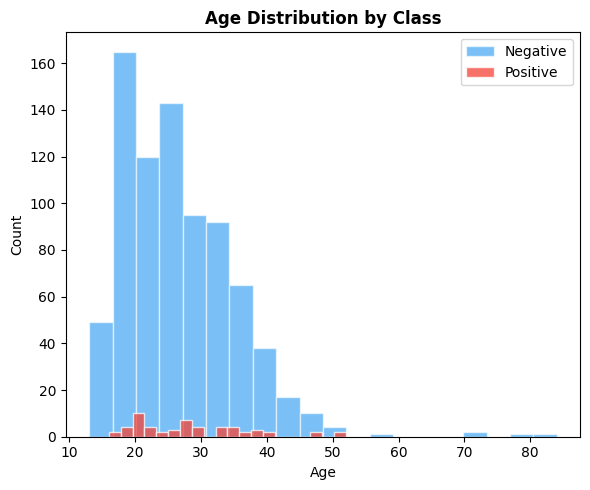

Median age — Negative: 25 years
Median age — Positive: 28 years

Observation: Positive cases tend to be slightly older,
but there is a lot of overlap — age alone cannot predict cancer.


In [8]:
fig, ax = plt.subplots(figsize=(6, 5))

# Overlapping histograms
data[data['Biopsy']==0]['Age'].plot(kind='hist', bins=20, alpha=0.6,
    color='#2196F3', label='Negative', ax=ax, edgecolor='white')

data[data['Biopsy']==1]['Age'].plot(kind='hist', bins=20, alpha=0.75,
    color='#F44336', label='Positive', ax=ax, edgecolor='white')

ax.set_title('Age Distribution by Class', fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.legend()

plt.tight_layout()
plt.show()

# Medians
neg_med = data[data['Biopsy']==0]['Age'].median()
pos_med = data[data['Biopsy']==1]['Age'].median()

print(f'Median age — Negative: {neg_med:.0f} years')
print(f'Median age — Positive: {pos_med:.0f} years')
print()
print('Observation: Positive cases tend to be slightly older,')
print('but there is a lot of overlap — age alone cannot predict cancer.')


### 2.3 — Key Feature Distributions

We look at the distribution of 6 important patient characteristics. The red dashed line marks the **median** of each feature.

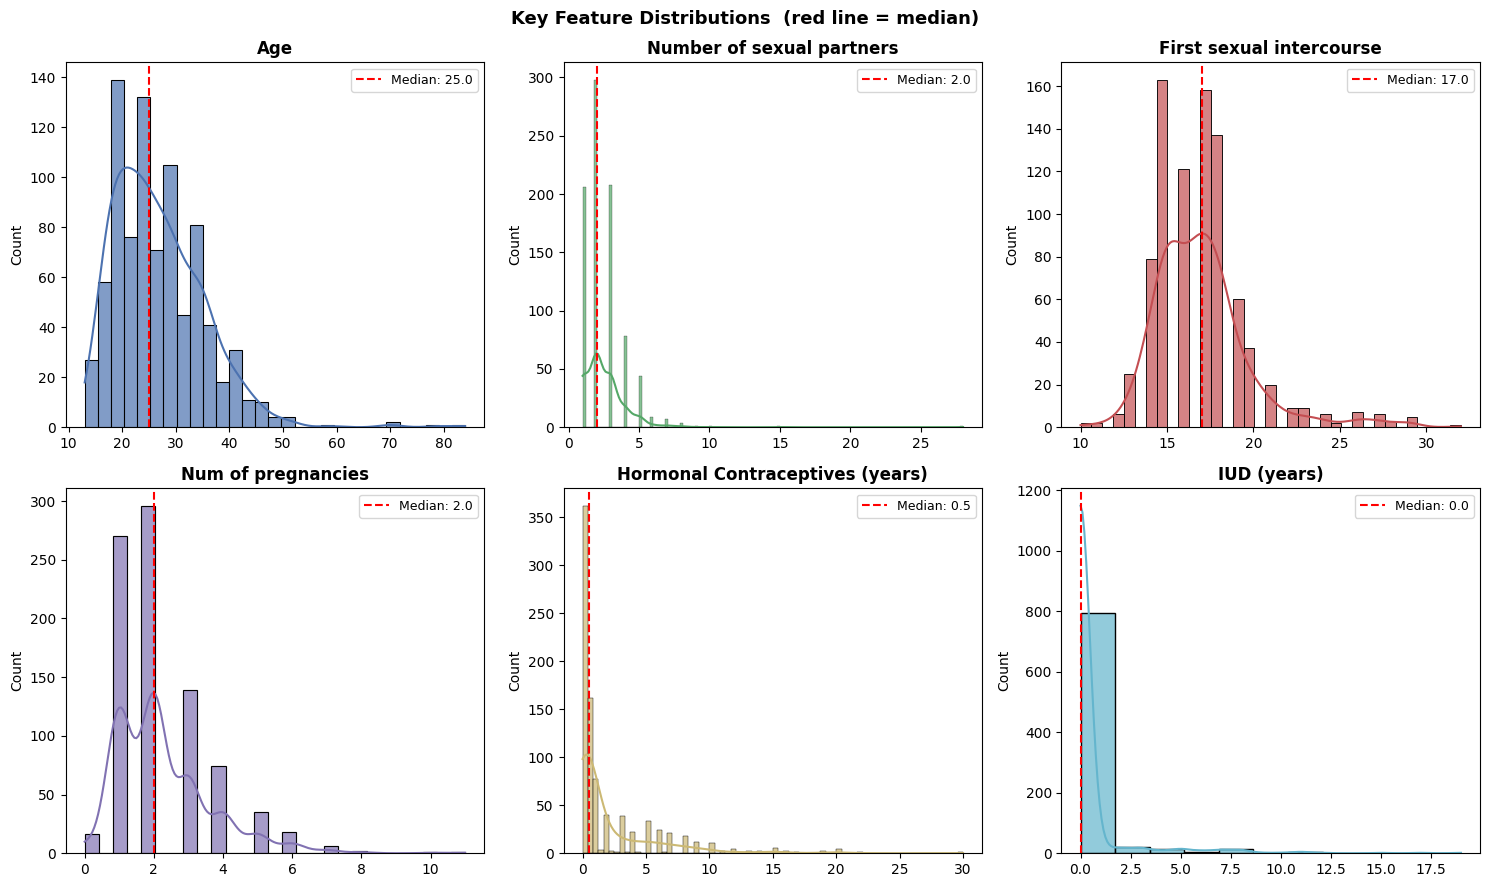

Key observations:
  • Most patients are young (peak ~25 years)
  • First intercourse typically at 15-18 years
  • Most patients have 1-3 pregnancies
  • IUD use is rare — most patients have 0 years of use
  • Hormonal contraceptive use varies widely


In [9]:
key_features = [
    'Age',
    'Number of sexual partners',
    'First sexual intercourse',
    'Num of pregnancies',
    'Hormonal Contraceptives (years)',
    'IUD (years)'
]
colors = ['#4C72B0','#55A868','#C44E52','#8172B2','#CCB974','#64B5CD']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for i, (col, color) in enumerate(zip(key_features, colors)):
    ax = axes[i // 3, i % 3]
    sns.histplot(data[col], kde=True, ax=ax, color=color, alpha=0.7)
    median_val = data[col].median()
    ax.axvline(median_val, color='red', linestyle='--',
               linewidth=1.5, label=f'Median: {median_val:.1f}')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=9)

plt.suptitle('Key Feature Distributions  (red line = median)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Key observations:')
print('  • Most patients are young (peak ~25 years)')
print('  • First intercourse typically at 15-18 years')
print('  • Most patients have 1-3 pregnancies')
print('  • IUD use is rare — most patients have 0 years of use')
print('  • Hormonal contraceptive use varies widely')

### 2.4 — Correlation Heatmap

This shows how every feature relates to every other feature.
- **Red** = positive correlation (both increase together)
- **Blue** = negative correlation (one increases, other decreases)
- **White** = no correlation

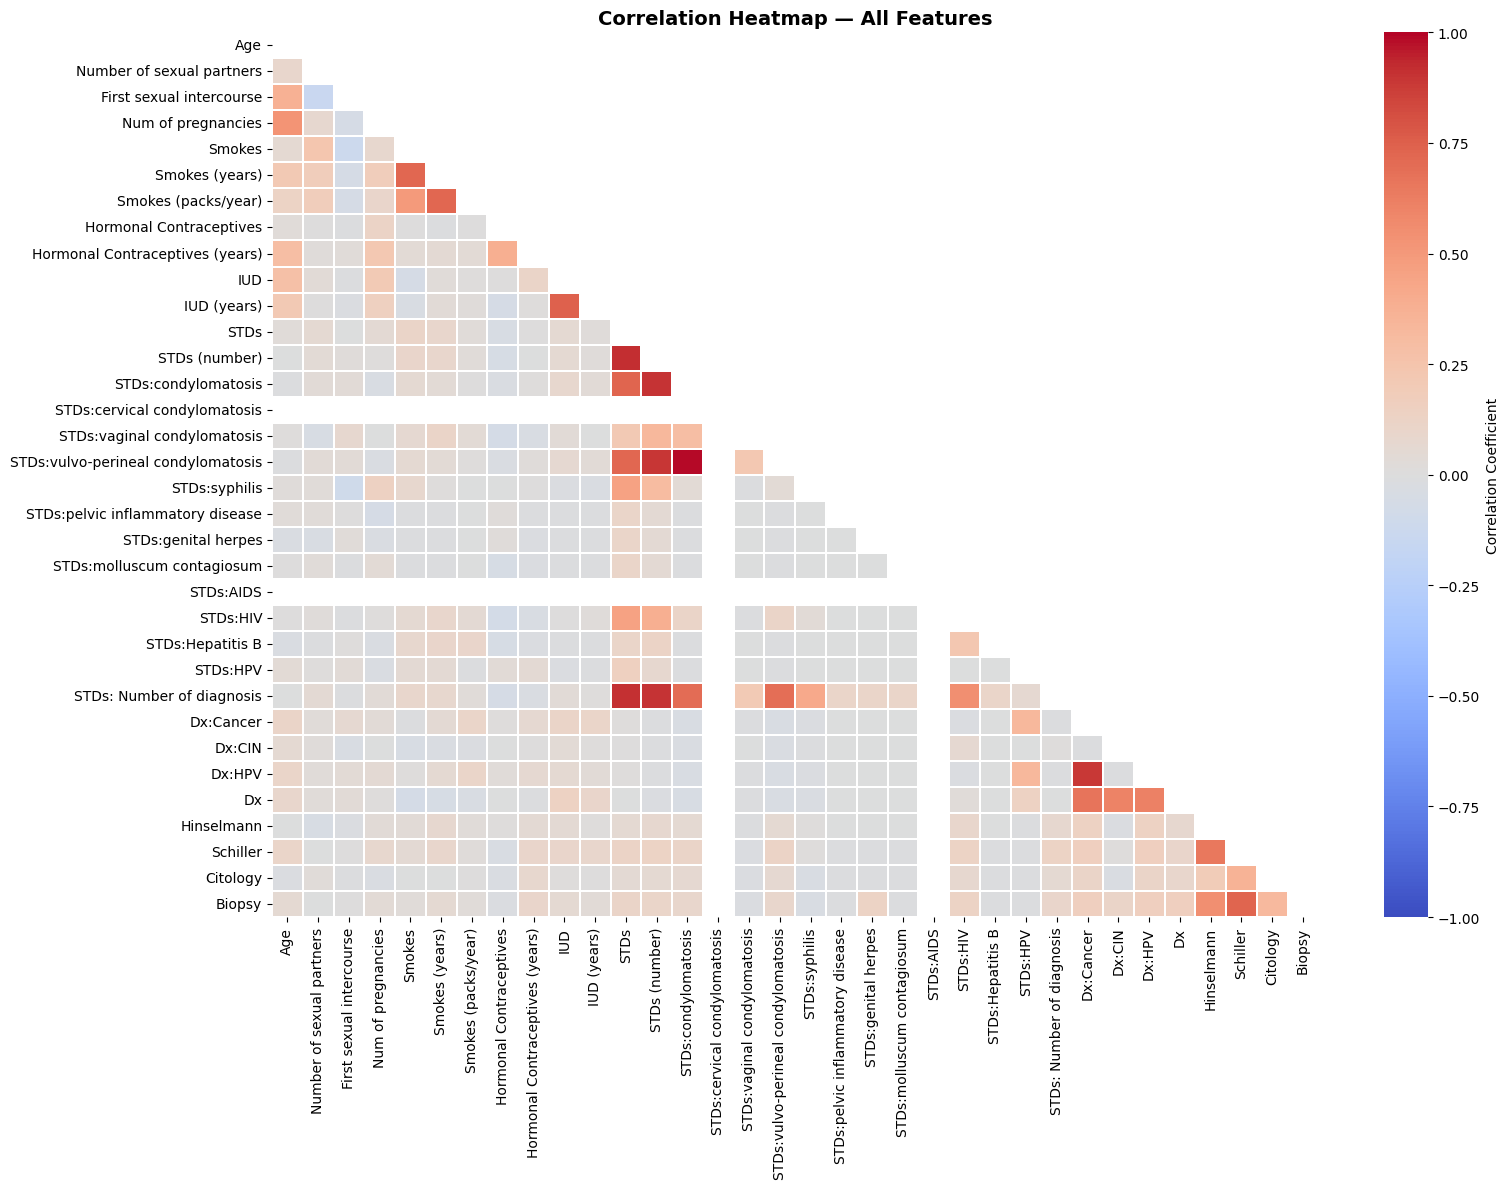

Key observation: STD-related columns are strongly correlated with each other.
Prior diagnosis columns (Dx:Cancer, Dx:HPV) correlate with Biopsy.


In [10]:
corr = data.corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))  # show only lower triangle
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm',
            linewidths=0.3, vmin=-1, vmax=1,
            cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Heatmap — All Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Key observation: STD-related columns are strongly correlated with each other.')
print('Prior diagnosis columns (Dx:Cancer, Dx:HPV) correlate with Biopsy.')

### 2.5 — Which Features Correlate Most with Biopsy?

This is the most useful chart for understanding which patient characteristics are actually associated with a positive cancer result.

**Red bars** = positively correlated with cancer (feature goes up → cancer risk goes up)
**Blue bars** = negatively correlated

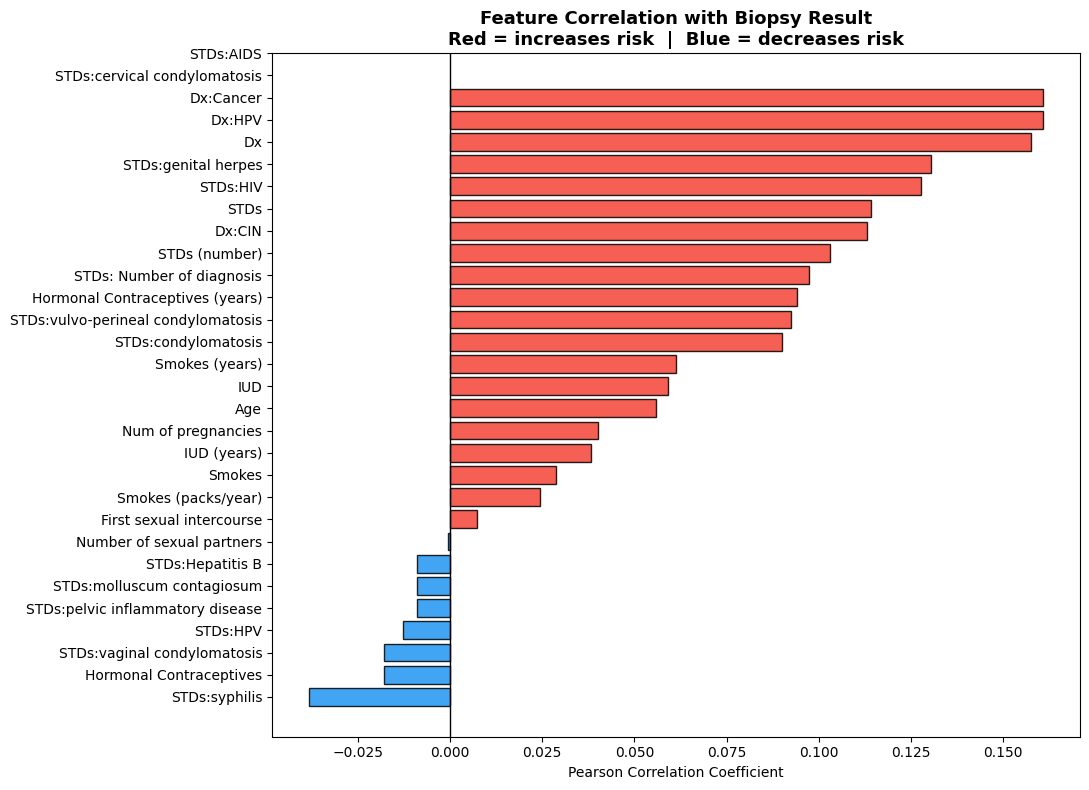

Top 5 features most correlated with a POSITIVE biopsy:
  +0.1609  →  Dx:Cancer
  +0.1609  →  Dx:HPV
  +0.1576  →  Dx
  +0.1305  →  STDs:genital herpes
  +0.1277  →  STDs:HIV

Conclusion:
  Prior diagnoses (Dx:Cancer, Dx:HPV, Dx) are the strongest predictors.
  STD history also increases risk. Age has a weak positive effect.


In [11]:
# We exclude the other 3 diagnostic test columns (Hinselmann, Schiller, Citology)
# because they are test results just like Biopsy — including them gives a misleading picture
target_corr = corr['Biopsy'].drop(
    ['Biopsy', 'Hinselmann', 'Schiller', 'Citology']
).sort_values(ascending=True)

bar_colors = ['#F44336' if v > 0 else '#2196F3' for v in target_corr]

plt.figure(figsize=(11, 8))
plt.barh(range(len(target_corr)), target_corr.values,
         color=bar_colors, edgecolor='black', alpha=0.85)
plt.yticks(range(len(target_corr)), target_corr.index, fontsize=10)
plt.axvline(0, color='black', linewidth=1)
plt.xlabel('Pearson Correlation Coefficient')
plt.title('Feature Correlation with Biopsy Result\n'
          'Red = increases risk  |  Blue = decreases risk',
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print('Top 5 features most correlated with a POSITIVE biopsy:')
top5 = target_corr.sort_values(ascending=False).head(5)
for feat, val in top5.items():
    print(f'  {val:+.4f}  →  {feat}')

print()
print('Conclusion:')
print('  Prior diagnoses (Dx:Cancer, Dx:HPV, Dx) are the strongest predictors.')
print('  STD history also increases risk. Age has a weak positive effect.')


# SECTION 3 — Data Preprocessing & Regularization



### 3.1 — Remove Data Leakage Columns

**Hinselmann, Schiller, and Citology** are also diagnostic test results — just like Biopsy. If we included them, the model would "cheat" by looking at those results instead of actually learning from the patient's medical history. We remove them before training.

In [12]:
data_clean = data.drop(columns=['Hinselmann', 'Schiller', 'Citology'])

X = data_clean.drop(columns=['Biopsy'])   # all features
y = data_clean['Biopsy']                  # what we want to predict

# Remove constant columns (same value for every patient = zero information)
constant_cols = X.columns[X.nunique() == 1]
if len(constant_cols) > 0:
    X = X.drop(columns=constant_cols)
    print(f'Removed constant columns: {list(constant_cols)}')

print(f'Feature matrix: {X.shape[0]} patients × {X.shape[1]} features')
print(f'\nAll features used for training:')
for col in X.columns:
    print(f'  • {col}')

Removed constant columns: ['STDs:cervical condylomatosis', 'STDs:AIDS']
Feature matrix: 858 patients × 28 features

All features used for training:
  • Age
  • Number of sexual partners
  • First sexual intercourse
  • Num of pregnancies
  • Smokes
  • Smokes (years)
  • Smokes (packs/year)
  • Hormonal Contraceptives
  • Hormonal Contraceptives (years)
  • IUD
  • IUD (years)
  • STDs
  • STDs (number)
  • STDs:condylomatosis
  • STDs:vaginal condylomatosis
  • STDs:vulvo-perineal condylomatosis
  • STDs:syphilis
  • STDs:pelvic inflammatory disease
  • STDs:genital herpes
  • STDs:molluscum contagiosum
  • STDs:HIV
  • STDs:Hepatitis B
  • STDs:HPV
  • STDs: Number of diagnosis
  • Dx:Cancer
  • Dx:CIN
  • Dx:HPV
  • Dx


### 3.2 — Feature Scaling (StandardScaler)

Features have very different ranges: Age goes from 10–84, while STD indicators are just 0 or 1. Without scaling, large-range features dominate small-range ones in distance-based models (SVM, KNN) and in regularization.

StandardScaler transforms each feature to have mean = 0 and standard deviation = 1.

In [13]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Show the effect on a few columns
sample_cols = ['Age', 'Number of sexual partners', 'Num of pregnancies']
comparison = pd.DataFrame({
    'Mean (before)': X[sample_cols].mean().round(2),
    'Mean (after)':  X_scaled[sample_cols].mean().round(4),
    'Std (before)':  X[sample_cols].std().round(2),
    'Std (after)':   X_scaled[sample_cols].std().round(4),
})
print('Effect of StandardScaler on sample columns:')
print(comparison)
print()
print('After scaling: all features have mean ≈ 0 and std ≈ 1')

Effect of StandardScaler on sample columns:
                           Mean (before)  Mean (after)  Std (before)  \
Age                                26.82          -0.0          8.50   
Number of sexual partners           2.51          -0.0          1.64   
Num of pregnancies                  2.26          -0.0          1.40   

                           Std (after)  
Age                             1.0006  
Number of sexual partners       1.0006  
Num of pregnancies              1.0006  

After scaling: all features have mean ≈ 0 and std ≈ 1


### 3.3 — Train / Test Split (80% / 20%)

We split the data so the model learns on 80% and is evaluated on a completely separate 20% it has never seen.

We use **stratified** splitting to ensure both sets maintain the same 6.4% positive class ratio.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Training set : {X_train.shape[0]} patients')
print(f'  Negative: {(y_train==0).sum()}  |  Positive: {(y_train==1).sum()}')
print()
print(f'Testing set  : {X_test.shape[0]} patients')
print(f'  Negative: {(y_test==0).sum()}  |  Positive: {(y_test==1).sum()}')

Training set : 686 patients
  Negative: 642  |  Positive: 44

Testing set  : 172 patients
  Negative: 161  |  Positive: 11


### 3.4 — Handle Class Imbalance: Oversampling

The training set has only **44 positive patients** vs **642 negative**. Without fixing this, every model predicts "negative" for everyone — 0% recall on cancer cases.

**Solution:** We randomly duplicate the positive minority class samples until the training set is balanced 50/50.

>  We only balance the **training** set. The test set stays at the real-world ratio.

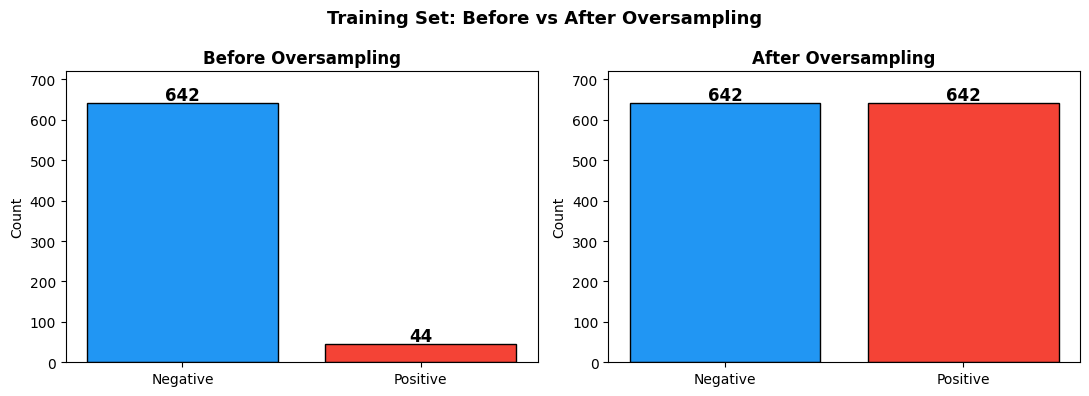

Total training samples after oversampling: 1284
  Negative: 642  |  Positive: 642


In [15]:
X_train_combined = pd.concat([X_train, y_train.rename('Biopsy')], axis=1)
majority = X_train_combined[X_train_combined['Biopsy'] == 0]
minority = X_train_combined[X_train_combined['Biopsy'] == 1]

minority_upsampled = resample(
    minority, replace=True,
    n_samples=len(majority),
    random_state=42
)
upsampled   = pd.concat([majority, minority_upsampled])
X_train_bal = upsampled.drop(columns=['Biopsy'])
y_train_bal = upsampled['Biopsy']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, vals, title in [
    (axes[0], [len(majority), len(minority)],              'Before Oversampling'),
    (axes[1], [(y_train_bal==0).sum(),(y_train_bal==1).sum()], 'After Oversampling')
]:
    bars = ax.bar(['Negative', 'Positive'], vals,
                  color=['#2196F3','#F44336'], edgecolor='black')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+8, str(v),
                ha='center', fontweight='bold', fontsize=12)
    ax.set_ylim(0, 720)

plt.suptitle('Training Set: Before vs After Oversampling', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Total training samples after oversampling: {len(y_train_bal)}')
print(f'  Negative: {(y_train_bal==0).sum()}  |  Positive: {(y_train_bal==1).sum()}')

### 3.5 — Regularization: Why We Chose Lasso (L1)

The project requires applying regularization. We chose between:

| | **Lasso (L1)** | **Ridge (L2)** |
|--|--|--|
| What it does | Pushes some coefficients to **exactly zero** | Shrinks all coefficients but keeps them all |
| Effect | **Automatic feature selection** | No feature selection |
| Best when | Many features, some are irrelevant | All features contribute |

**Our choice: Lasso (L1)**

We have 28 features and from the correlation chart we already see that many have very low correlation with Biopsy. Lasso will automatically identify and eliminate those irrelevant features, giving us a cleaner model. Ridge would keep all 28 features even if most add no value.

In [16]:
lasso = Lasso(alpha=0.01)  # alpha controls regularization strength
lasso.fit(X_train_bal, y_train_bal)

lasso_coefs = pd.Series(lasso.coef_, index=X.columns)
kept    = lasso_coefs[lasso_coefs != 0]
removed = lasso_coefs[lasso_coefs == 0]

print(f'Total features:       {len(lasso_coefs)}')
print(f'Features KEPT:        {len(kept)}')
print(f'Features ELIMINATED:  {len(removed)}')
print()
print('Features eliminated by Lasso (coefficient driven to zero):')
for col in removed.index:
    print(f' .  {col}')

Total features:       28
Features KEPT:        19
Features ELIMINATED:  9

Features eliminated by Lasso (coefficient driven to zero):
 .  Number of sexual partners
 .  Smokes
 .  Smokes (packs/year)
 .  STDs (number)
 .  STDs:condylomatosis
 .  STDs:pelvic inflammatory disease
 .  STDs:genital herpes
 .  STDs:molluscum contagiosum
 .  STDs: Number of diagnosis


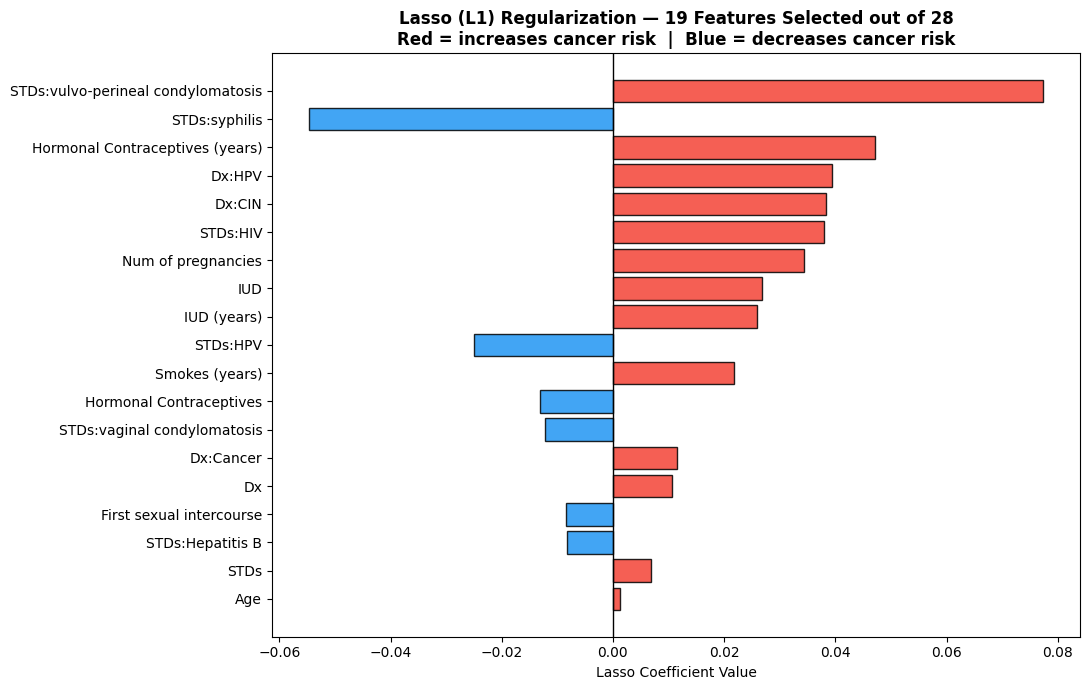

How to read this:
  Red bars: feature is associated with higher cancer risk
  Blue bars: feature is associated with lower cancer risk
  Longer bar = stronger effect

The features NOT shown were eliminated by Lasso (coefficient = 0).


In [17]:
# Visualize the features Lasso kept
kept_sorted = kept.sort_values(key=abs, ascending=True)
bar_colors  = ['#F44336' if v > 0 else '#2196F3' for v in kept_sorted]

plt.figure(figsize=(11, 7))
plt.barh(range(len(kept_sorted)), kept_sorted.values,
         color=bar_colors, edgecolor='black', alpha=0.85)
plt.yticks(range(len(kept_sorted)), kept_sorted.index, fontsize=10)
plt.axvline(0, color='black', linewidth=1)
plt.xlabel('Lasso Coefficient Value')
plt.title(f'Lasso (L1) Regularization — {len(kept)} Features Selected out of {len(lasso_coefs)}\n'
          'Red = increases cancer risk  |  Blue = decreases cancer risk',
          fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print('How to read this:')
print('  Red bars: feature is associated with higher cancer risk')
print('  Blue bars: feature is associated with lower cancer risk')
print('  Longer bar = stronger effect')
print()
print('The features NOT shown were eliminated by Lasso (coefficient = 0).')


#SECTION 4 — Model Selection & Training


We trained **5 models** to have a comprehensive comparison.

| Model | How it works |
|-------|--------------|
| **Logistic Regression** | Finds a linear boundary between the two classes |
| **Random Forest** | 100 decision trees vote — majority wins |
| **SVM** | Finds the widest possible boundary between classes |
| **KNN** | Classifies based on the 5 nearest training points |
| **Gradient Boosting** | Trees that sequentially correct each other's errors |



In [18]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM':                 SVC(kernel='rbf', probability=True),
    'KNN':                 KNeighborsClassifier(n_neighbors=5),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42)
}

print('Training all 5 models on the balanced training set...')
for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    print(f'  .  {name}')


Training all 5 models on the balanced training set...
  .  Logistic Regression
  .  Random Forest
  .  SVM
  .  KNN
  .  Gradient Boosting



# SECTION 5 — Model Evaluation
Evaluate using appropriate metrics: accuracy, precision, recall, F1-score. Discuss correlations found and best features.*

**Metric definitions:**
- **Accuracy** — % of all predictions correct *(misleading here due to imbalance)*
- **Precision** — of patients flagged as positive, how many actually are?
- **Recall** — of all actual positive patients, how many did we catch? *(most important in medicine)*
- **F1 Score** — harmonic mean of precision and recall *(our main metric)*
- **AUC** — ability to separate the two classes overall (1.0 = perfect, 0.5 = random)



### 5.1 — Classification Report for Each Model

In [19]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred,
                                 target_names=['Negative (0)', 'Positive (1)']))
    print()

  Logistic Regression
              precision    recall  f1-score   support

Negative (0)       0.95      0.84      0.89       161
Positive (1)       0.13      0.36      0.20        11

    accuracy                           0.81       172
   macro avg       0.54      0.60      0.54       172
weighted avg       0.90      0.81      0.85       172


  Random Forest
              precision    recall  f1-score   support

Negative (0)       0.94      0.98      0.96       161
Positive (1)       0.25      0.09      0.13        11

    accuracy                           0.92       172
   macro avg       0.60      0.54      0.55       172
weighted avg       0.90      0.92      0.91       172


  SVM
              precision    recall  f1-score   support

Negative (0)       0.94      0.94      0.94       161
Positive (1)       0.09      0.09      0.09        11

    accuracy                           0.88       172
   macro avg       0.51      0.51      0.51       172
weighted avg       0.88     

### 5.2 — Model Comparison Table

In [20]:
results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    results.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1 Score':  round(f1_score(y_test, y_pred, zero_division=0), 4),
        'AUC':       round(roc_auc_score(y_test, model.predict_proba(X_test)[:,1]), 4)
    })

results_df = pd.DataFrame(results).set_index('Model')
print('=== Model Comparison ===')
print(results_df.to_string())

best_name = results_df['F1 Score'].idxmax()
best_recall = results_df['Recall'].idxmax()
best_auc    = results_df['AUC'].idxmax()
print(f'\nBest F1 Score:  {best_name} ({results_df.loc[best_name, "F1 Score"]})')
print(f'Best Recall:    {best_recall} ({results_df.loc[best_recall, "Recall"]})')
print(f'Best AUC:       {best_auc} ({results_df.loc[best_auc, "AUC"]})')

=== Model Comparison ===
                     Accuracy  Precision  Recall  F1 Score     AUC
Model                                                             
Logistic Regression    0.8081     0.1333  0.3636    0.1951  0.6364
Random Forest          0.9244     0.2500  0.0909    0.1333  0.6925
SVM                    0.8837     0.0909  0.0909    0.0909  0.6640
KNN                    0.7965     0.1000  0.2727    0.1463  0.6383
Gradient Boosting      0.8314     0.0909  0.1818    0.1212  0.6053

Best F1 Score:  Logistic Regression (0.1951)
Best Recall:    Logistic Regression (0.3636)
Best AUC:       Random Forest (0.6925)


### 5.3 — Visual Comparison of All Models

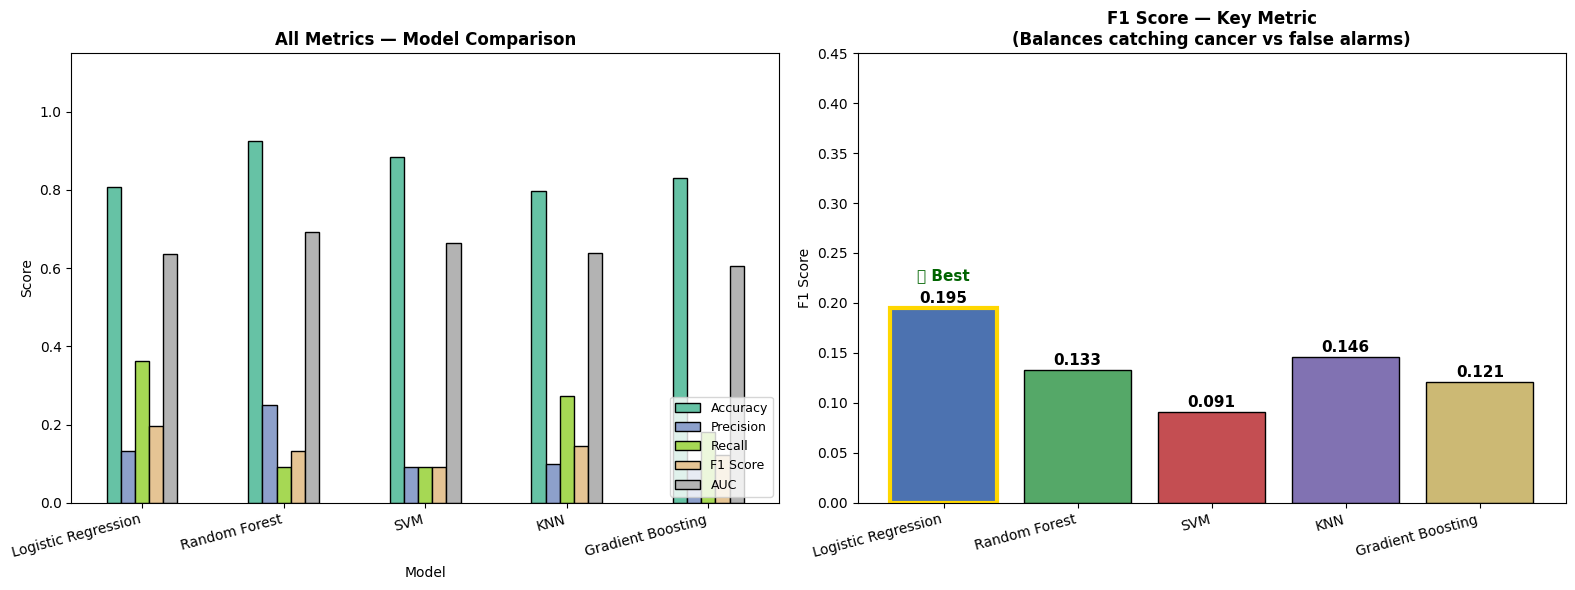

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
bar_colors = ['#4C72B0','#55A868','#C44E52','#8172B2','#CCB974']

# All metrics
results_df[['Accuracy','Precision','Recall','F1 Score','AUC']].plot(
    kind='bar', ax=axes[0], colormap='Set2', edgecolor='black')
axes[0].set_title('All Metrics — Model Comparison', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Score')
axes[0].set_xticklabels(results_df.index, rotation=15, ha='right')
axes[0].set_ylim(0, 1.15)
axes[0].legend(loc='lower right', fontsize=9)

# F1 Score only (key metric)
bars = axes[1].bar(results_df.index, results_df['F1 Score'],
                    color=bar_colors, edgecolor='black')
axes[1].set_title('F1 Score — Key Metric\n(Balances catching cancer vs false alarms)',
                   fontweight='bold', fontsize=12)
axes[1].set_ylabel('F1 Score')
axes[1].set_xticklabels(results_df.index, rotation=15, ha='right')
axes[1].set_ylim(0, 0.45)
for i, (bar, v) in enumerate(zip(bars, results_df['F1 Score'])):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.005,
                 f'{v:.3f}', ha='center', fontweight='bold', fontsize=11)
    if results_df.index[i] == best_name:
        bar.set_edgecolor('gold')
        bar.set_linewidth(3)
        axes[1].text(bar.get_x()+bar.get_width()/2, v+0.028,
                     '🏆 Best', ha='center', fontsize=11,
                     color='darkgreen', fontweight='bold')

plt.tight_layout()
plt.show()

### 5.4 — ROC Curves

The ROC curve shows how well each model separates positive from negative cases at different thresholds. **AUC closer to 1.0 = better.** The diagonal line represents random guessing (AUC = 0.5).

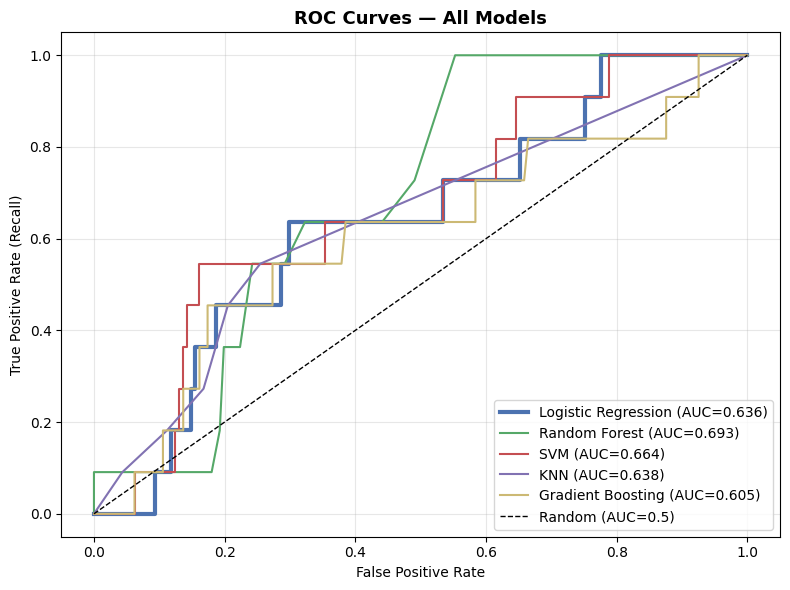

In [22]:
plt.figure(figsize=(8, 6))
line_colors = ['#4C72B0','#55A868','#C44E52','#8172B2','#CCB974']

for (name, model), color in zip(models.items(), line_colors):
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:,1])
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    lw  = 3 if name == best_name else 1.5
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})',
             linewidth=lw, color=color)

plt.plot([0,1],[0,1],'--k', linewidth=1, label='Random (AUC=0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curves — All Models', fontweight='bold', fontsize=13)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.5 — Confusion Matrix of the Best Model

Reading the matrix:
- **Top-left** = True Negative: correctly said "no cancer"
- **Bottom-right** = True Positive: correctly caught cancer
- **Top-right** = False Positive: raised a false alarm
- **Bottom-left** = False Negative: **missed a cancer case** ← worst error in medicine

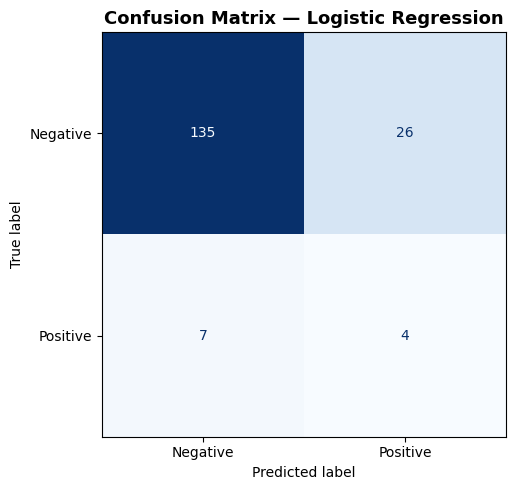

True Negatives  (correctly said no cancer):  135
False Positives (false alarm):               26
False Negatives (missed cancer!):            7  ← want this as low as possible
True Positives  (cancer correctly caught):   4  ← want this as high as possible


In [23]:
best_model  = models[best_name]
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=['Negative', 'Positive']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_name}', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (correctly said no cancer):  {tn}')
print(f'False Positives (false alarm):               {fp}')
print(f'False Negatives (missed cancer!):            {fn}  ← want this as low as possible')
print(f'True Positives  (cancer correctly caught):   {tp}  ← want this as high as possible')

### 5.6 — Feature Importance (Best Features Identified)

Using Random Forest's built-in feature importance to identify which patient characteristics matter most for prediction.

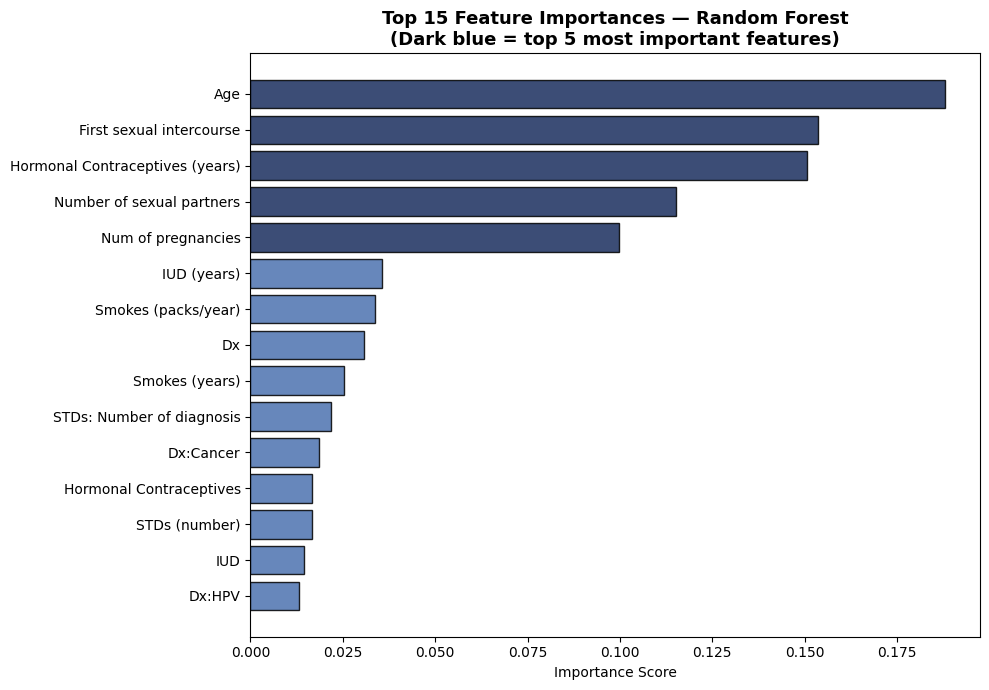

Top 5 most important features for predicting cervical cancer:
  0.1880  →  Age
  0.1536  →  First sexual intercourse
  0.1506  →  Hormonal Contraceptives (years)
  0.1152  →  Number of sexual partners
  0.0998  →  Num of pregnancies


In [24]:
rf_model = models['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top15 = importances.sort_values(ascending=True).tail(15)

colors_imp = ['#1A2E5E' if i >= 10 else '#4C72B0' for i in range(len(top15))]

plt.figure(figsize=(10, 7))
plt.barh(range(len(top15)), top15.values,
         color=colors_imp, edgecolor='black', alpha=0.85)
plt.yticks(range(len(top15)), top15.index, fontsize=10)
plt.xlabel('Importance Score')
plt.title('Top 15 Feature Importances — Random Forest\n'
          '(Dark blue = top 5 most important features)',
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print('Top 5 most important features for predicting cervical cancer:')
for feat, val in top15.tail(5).sort_values(ascending=False).items():
    print(f'  {val:.4f}  →  {feat}')

### 5.7 — Midterm Summary

A complete summary of everything we found and built for the midterm.

In [25]:
best_metrics = results_df.loc[best_name]

print('  MIDTERM PROJECT SUMMARY')
print()
print('DATASET')
print('  858 patients  |  36 features  |  UCI Cervical Cancer')
print(f'  Target: Biopsy (6.4% positive — severe class imbalance)')
print()
print('DATA PREPARATION')
print('  • Loaded CSV with na_values="?" to handle missing data')
print('  • Dropped 2 columns with >90% missing (STDs time features)')
print('  • Filled remaining missing values with median imputation')
print('  • Removed 3 data leakage columns (Hinselmann, Schiller, Citology)')
print()
print('EDA FINDINGS')
print('  • Only 6.4% positive cases — heavily imbalanced dataset')
print('  • Strongest predictors: Dx:Cancer, Dx:HPV, Dx (prior diagnoses)')
print('  • STD history also correlated with positive biopsy')
print('  • Accuracy is misleading here — F1 Score is our key metric')
print()
print('PREPROCESSING')
print('  • StandardScaler: normalized all features to mean=0, std=1')
print('  • 80/20 stratified train/test split')
print('  • Oversampling: balanced training set to 642 vs 642')
print()
print('REGULARIZATION — Lasso (L1) chosen over Ridge (L2)')
print('  Reason: many features, need feature selection to identify')
print('  which ones actually matter. Lasso eliminates irrelevant ones.')
print(f'  Result: {len(kept)} features kept, {len(removed)} features eliminated')
print()
print('MODEL RESULTS (5 classifiers trained)')
for _, row in pd.DataFrame(results).iterrows():
    marker = '  ← BEST (F1)' if row['Model'] == best_name else ''
    print(f"  {row['Model']:22}  Accuracy={row['Accuracy']:.3f}  "
          f"F1={row['F1 Score']:.3f}  Recall={row['Recall']:.3f}{marker}")
print()
print(f'BEST MODEL: {best_name}')
print(f'  Accuracy:  {best_metrics["Accuracy"]*100:.1f}%')
print(f'  Precision: {best_metrics["Precision"]*100:.1f}%')
print(f'  Recall:    {best_metrics["Recall"]*100:.1f}%  (catches {best_metrics["Recall"]*100:.0f}% of actual cancer cases)')
print(f'  F1 Score:  {best_metrics["F1 Score"]*100:.1f}%')
print('='*60)

  MIDTERM PROJECT SUMMARY

DATASET
  858 patients  |  36 features  |  UCI Cervical Cancer
  Target: Biopsy (6.4% positive — severe class imbalance)

DATA PREPARATION
  • Loaded CSV with na_values="?" to handle missing data
  • Dropped 2 columns with >90% missing (STDs time features)
  • Filled remaining missing values with median imputation
  • Removed 3 data leakage columns (Hinselmann, Schiller, Citology)

EDA FINDINGS
  • Only 6.4% positive cases — heavily imbalanced dataset
  • Strongest predictors: Dx:Cancer, Dx:HPV, Dx (prior diagnoses)
  • STD history also correlated with positive biopsy
  • Accuracy is misleading here — F1 Score is our key metric

PREPROCESSING
  • StandardScaler: normalized all features to mean=0, std=1
  • 80/20 stratified train/test split
  • Oversampling: balanced training set to 642 vs 642

REGULARIZATION — Lasso (L1) chosen over Ridge (L2)
  Reason: many features, need feature selection to identify
  which ones actually matter. Lasso eliminates irrelevant

---
---

# PART 2 — FINAL PRESENTATION

---

**This section continues from the midterm and covers the Final Presentation requirements:**
1. **PCA for Feature Selection** — Apply PCA, compare all models with and without PCA
2. **Hyperparameter Tuning** — Grid Search & Random Search for each model, with and without PCA
3. **Comprehensive Model Evaluation** — Compare all configurations and justify the best model
4. **Visualization** — Informative charts for every comparison
5. **Conclusion** — Findings, practical implications, and future improvements

### Additional Imports for the Final Part

In [26]:
# Additional imports needed for the final part
import time
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.decomposition import PCA
from scipy.stats import randint, uniform

print('Additional libraries imported for the final part.')

Additional libraries imported for the final part.


### Store Midterm Baseline in a Reusable Format

We save the midterm model results in a standardized format so we can compare them against the PCA and tuned versions later.

In [27]:
# ── Reusable evaluation function ──
def evaluate_model(model, X_te, y_te):
    """Compute all metrics for a trained model."""
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    return {
        'Accuracy':  round(accuracy_score(y_te, y_pred), 4),
        'Precision': round(precision_score(y_te, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_te, y_pred, zero_division=0), 4),
        'F1 Score':  round(f1_score(y_te, y_pred, zero_division=0), 4),
        'AUC':       round(roc_auc_score(y_te, y_prob), 4)
    }

# ── Store midterm baseline results in a standard list ──
# (the midterm 'models' dict and 'results_df' are already in memory)
baseline_models = models  # reference the dict trained in the midterm

baseline_results = []
for name, model in baseline_models.items():
    metrics = evaluate_model(model, X_test, y_test)
    metrics.update({'Model': name, 'Config': 'Baseline (No PCA)'})
    baseline_results.append(metrics)

baseline_df = pd.DataFrame(baseline_results).set_index('Model')
print('Midterm baseline results stored:')
print(baseline_df[['F1 Score', 'AUC', 'Recall', 'Precision']].to_string())

Midterm baseline results stored:
                     F1 Score     AUC  Recall  Precision
Model                                                   
Logistic Regression    0.1951  0.6364  0.3636     0.1333
Random Forest          0.1333  0.6925  0.0909     0.2500
SVM                    0.0909  0.6640  0.0909     0.0909
KNN                    0.1463  0.6383  0.2727     0.1000
Gradient Boosting      0.1212  0.6053  0.1818     0.0909


---

# SECTION 6 — PCA for Feature Selection

**Principal Component Analysis (PCA)** reduces the number of features while retaining as much information (variance) as possible.

**Why PCA here?**
- We have 28 features — many are correlated (e.g., all STD-related columns)
- PCA creates new **uncorrelated** principal components that capture the most variance
- Fewer features can reduce overfitting, reduce noise, and speed up training

**Our approach:**
1. Fit PCA on all components and analyze the explained variance
2. Choose the number of components that captures ≥ 95% of the total variance
3. Re-train all 5 models on the PCA-reduced features
4. Compare results with and without PCA

### 6.1 — Explained Variance Analysis

We fit PCA with all 28 components to see how many we actually need to keep 95% of the information.

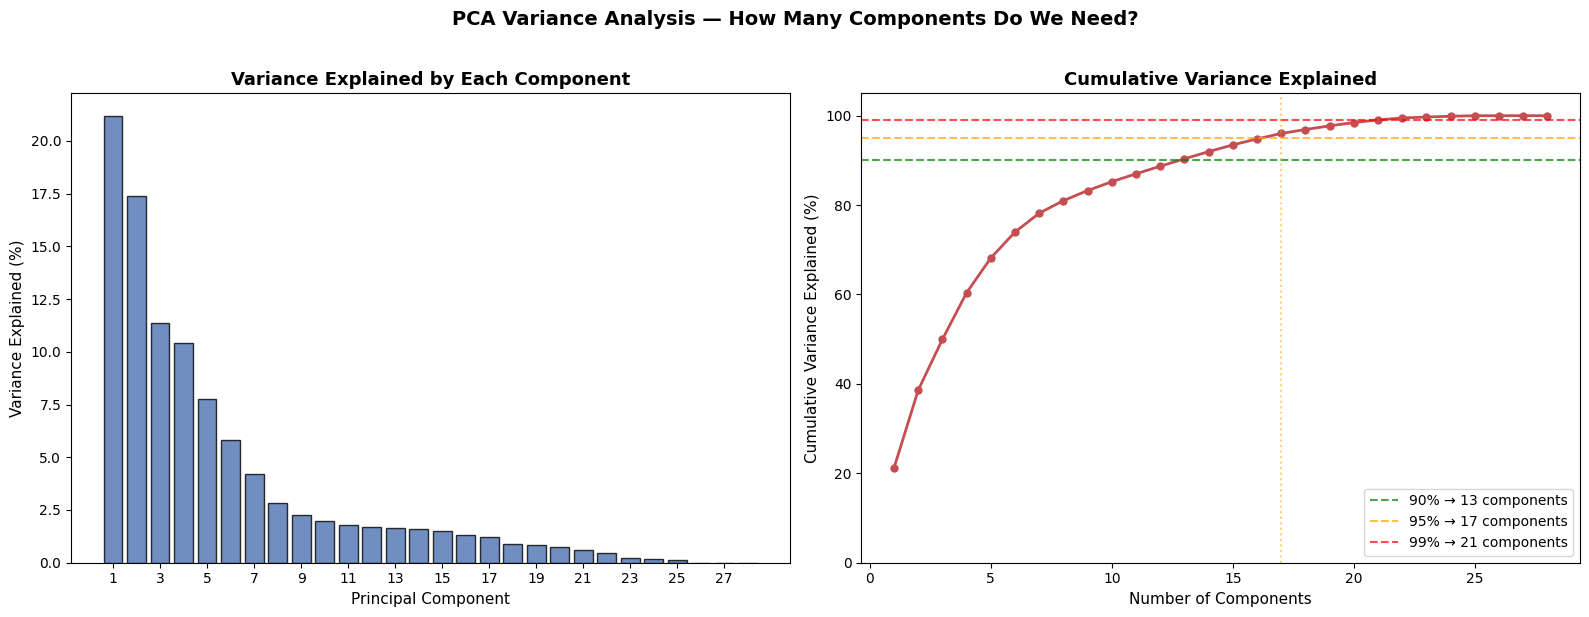

Total features:                    28
Components for 90% variance:       13
Components for 95% variance:       17  ← OUR CHOICE
Components for 99% variance:       21

With 17 components we keep 95% of the information
while reducing from 28 to 17 features (39% reduction).


In [28]:
# Fit PCA with ALL components to analyze variance
pca_full = PCA(n_components=X_train_bal.shape[1], random_state=42)
pca_full.fit(X_train_bal)

explained_var  = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# Thresholds
n_90 = np.argmax(cumulative_var >= 0.90) + 1
n_95 = np.argmax(cumulative_var >= 0.95) + 1
n_99 = np.argmax(cumulative_var >= 0.99) + 1

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: individual variance per component
axes[0].bar(range(1, len(explained_var)+1), explained_var * 100,
            color='#4C72B0', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Principal Component', fontsize=11)
axes[0].set_ylabel('Variance Explained (%)', fontsize=11)
axes[0].set_title('Variance Explained by Each Component', fontweight='bold', fontsize=13)
axes[0].set_xticks(range(1, len(explained_var)+1, 2))

# Right: cumulative variance
axes[1].plot(range(1, len(cumulative_var)+1), cumulative_var * 100,
             'o-', color='#C44E52', linewidth=2, markersize=5)
axes[1].axhline(y=90,  color='green',  linestyle='--', alpha=0.7, label=f'90% → {n_90} components')
axes[1].axhline(y=95,  color='orange', linestyle='--', alpha=0.7, label=f'95% → {n_95} components')
axes[1].axhline(y=99,  color='red',    linestyle='--', alpha=0.7, label=f'99% → {n_99} components')
axes[1].axvline(x=n_95, color='orange', linestyle=':', alpha=0.5)
axes[1].set_xlabel('Number of Components', fontsize=11)
axes[1].set_ylabel('Cumulative Variance Explained (%)', fontsize=11)
axes[1].set_title('Cumulative Variance Explained', fontweight='bold', fontsize=13)
axes[1].legend(fontsize=10, loc='lower right')
axes[1].set_ylim(0, 105)

plt.suptitle('PCA Variance Analysis — How Many Components Do We Need?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Total features:                    {X_train_bal.shape[1]}')
print(f'Components for 90% variance:       {n_90}')
print(f'Components for 95% variance:       {n_95}  ← OUR CHOICE')
print(f'Components for 99% variance:       {n_99}')
print(f'\nWith {n_95} components we keep 95% of the information')
print(f'while reducing from {X_train_bal.shape[1]} to {n_95} features ({100 - n_95/X_train_bal.shape[1]*100:.0f}% reduction).')

### 6.2 — Apply PCA (95% Variance Threshold)

We transform both training and test sets using the chosen number of components.

In [29]:
# Apply PCA with 95% variance threshold
n_components = n_95
pca = PCA(n_components=n_components, random_state=42)
X_train_pca = pca.fit_transform(X_train_bal)
X_test_pca  = pca.transform(X_test)

print(f'PCA applied: {X_train_bal.shape[1]} original features → {n_components} principal components')
print(f'Variance retained: {pca.explained_variance_ratio_.sum()*100:.2f}%')
print(f'\nTraining set shape: {X_train_pca.shape}')
print(f'Test set shape:     {X_test_pca.shape}')

PCA applied: 28 original features → 17 principal components
Variance retained: 96.02%

Training set shape: (1284, 17)
Test set shape:     (172, 17)


### 6.3 — Train All Models WITH PCA and Compare to Baseline

In [30]:
# Train all 5 models on PCA-transformed data
pca_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM':                 SVC(kernel='rbf', probability=True),
    'KNN':                 KNeighborsClassifier(n_neighbors=5),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42)
}

pca_results = []
print(f'Training all models with PCA ({n_components} components)...')
for name, model in pca_models.items():
    model.fit(X_train_pca, y_train_bal)
    metrics = evaluate_model(model, X_test_pca, y_test)
    metrics.update({'Model': name, 'Config': 'With PCA'})
    pca_results.append(metrics)
    print(f'  ✓ {name:25s}  F1={metrics["F1 Score"]:.4f}  AUC={metrics["AUC"]:.4f}')

pca_df = pd.DataFrame(pca_results).set_index('Model')

Training all models with PCA (17 components)...
  ✓ Logistic Regression        F1=0.1333  AUC=0.5488
  ✓ Random Forest              F1=0.1333  AUC=0.7199
  ✓ SVM                        F1=0.0833  AUC=0.6827
  ✓ KNN                        F1=0.1176  AUC=0.5776
  ✓ Gradient Boosting          F1=0.2105  AUC=0.5438


### 6.4 — PCA vs No PCA: Detailed Comparison Table

In [31]:
# Build comparison table
comparison_data = []
for model_name in baseline_df.index:
    b = baseline_df.loc[model_name]
    p = pca_df.loc[model_name]
    comparison_data.append({
        'Model': model_name,
        'F1 (No PCA)':    b['F1 Score'],
        'F1 (With PCA)':  p['F1 Score'],
        'F1 Change':      round(p['F1 Score'] - b['F1 Score'], 4),
        'AUC (No PCA)':   b['AUC'],
        'AUC (With PCA)': p['AUC'],
        'AUC Change':     round(p['AUC'] - b['AUC'], 4),
        'Recall (No PCA)':   b['Recall'],
        'Recall (With PCA)': p['Recall'],
    })

comparison_df = pd.DataFrame(comparison_data).set_index('Model')
print('═══ PCA IMPACT ON MODEL PERFORMANCE ═══')
print()
print(comparison_df.to_string())
print()

for metric in ['F1', 'AUC']:
    col = f'{metric} Change'
    improved = (comparison_df[col] > 0).sum()
    degraded = (comparison_df[col] < 0).sum()
    same     = (comparison_df[col] == 0).sum()
    print(f'{metric}: {improved} model(s) improved, {degraded} degraded, {same} unchanged with PCA')

═══ PCA IMPACT ON MODEL PERFORMANCE ═══

                     F1 (No PCA)  F1 (With PCA)  F1 Change  AUC (No PCA)  AUC (With PCA)  AUC Change  Recall (No PCA)  Recall (With PCA)
Model                                                                                                                                   
Logistic Regression       0.1951         0.1333    -0.0618        0.6364          0.5488     -0.0876           0.3636             0.2727
Random Forest             0.1333         0.1333     0.0000        0.6925          0.7199      0.0274           0.0909             0.0909
SVM                       0.0909         0.0833    -0.0076        0.6640          0.6827      0.0187           0.0909             0.0909
KNN                       0.1463         0.1176    -0.0287        0.6383          0.5776     -0.0607           0.2727             0.1818
Gradient Boosting         0.1212         0.2105     0.0893        0.6053          0.5438     -0.0615           0.1818             0.1818


### 6.5 — Visualization: PCA vs No PCA (All Metrics)

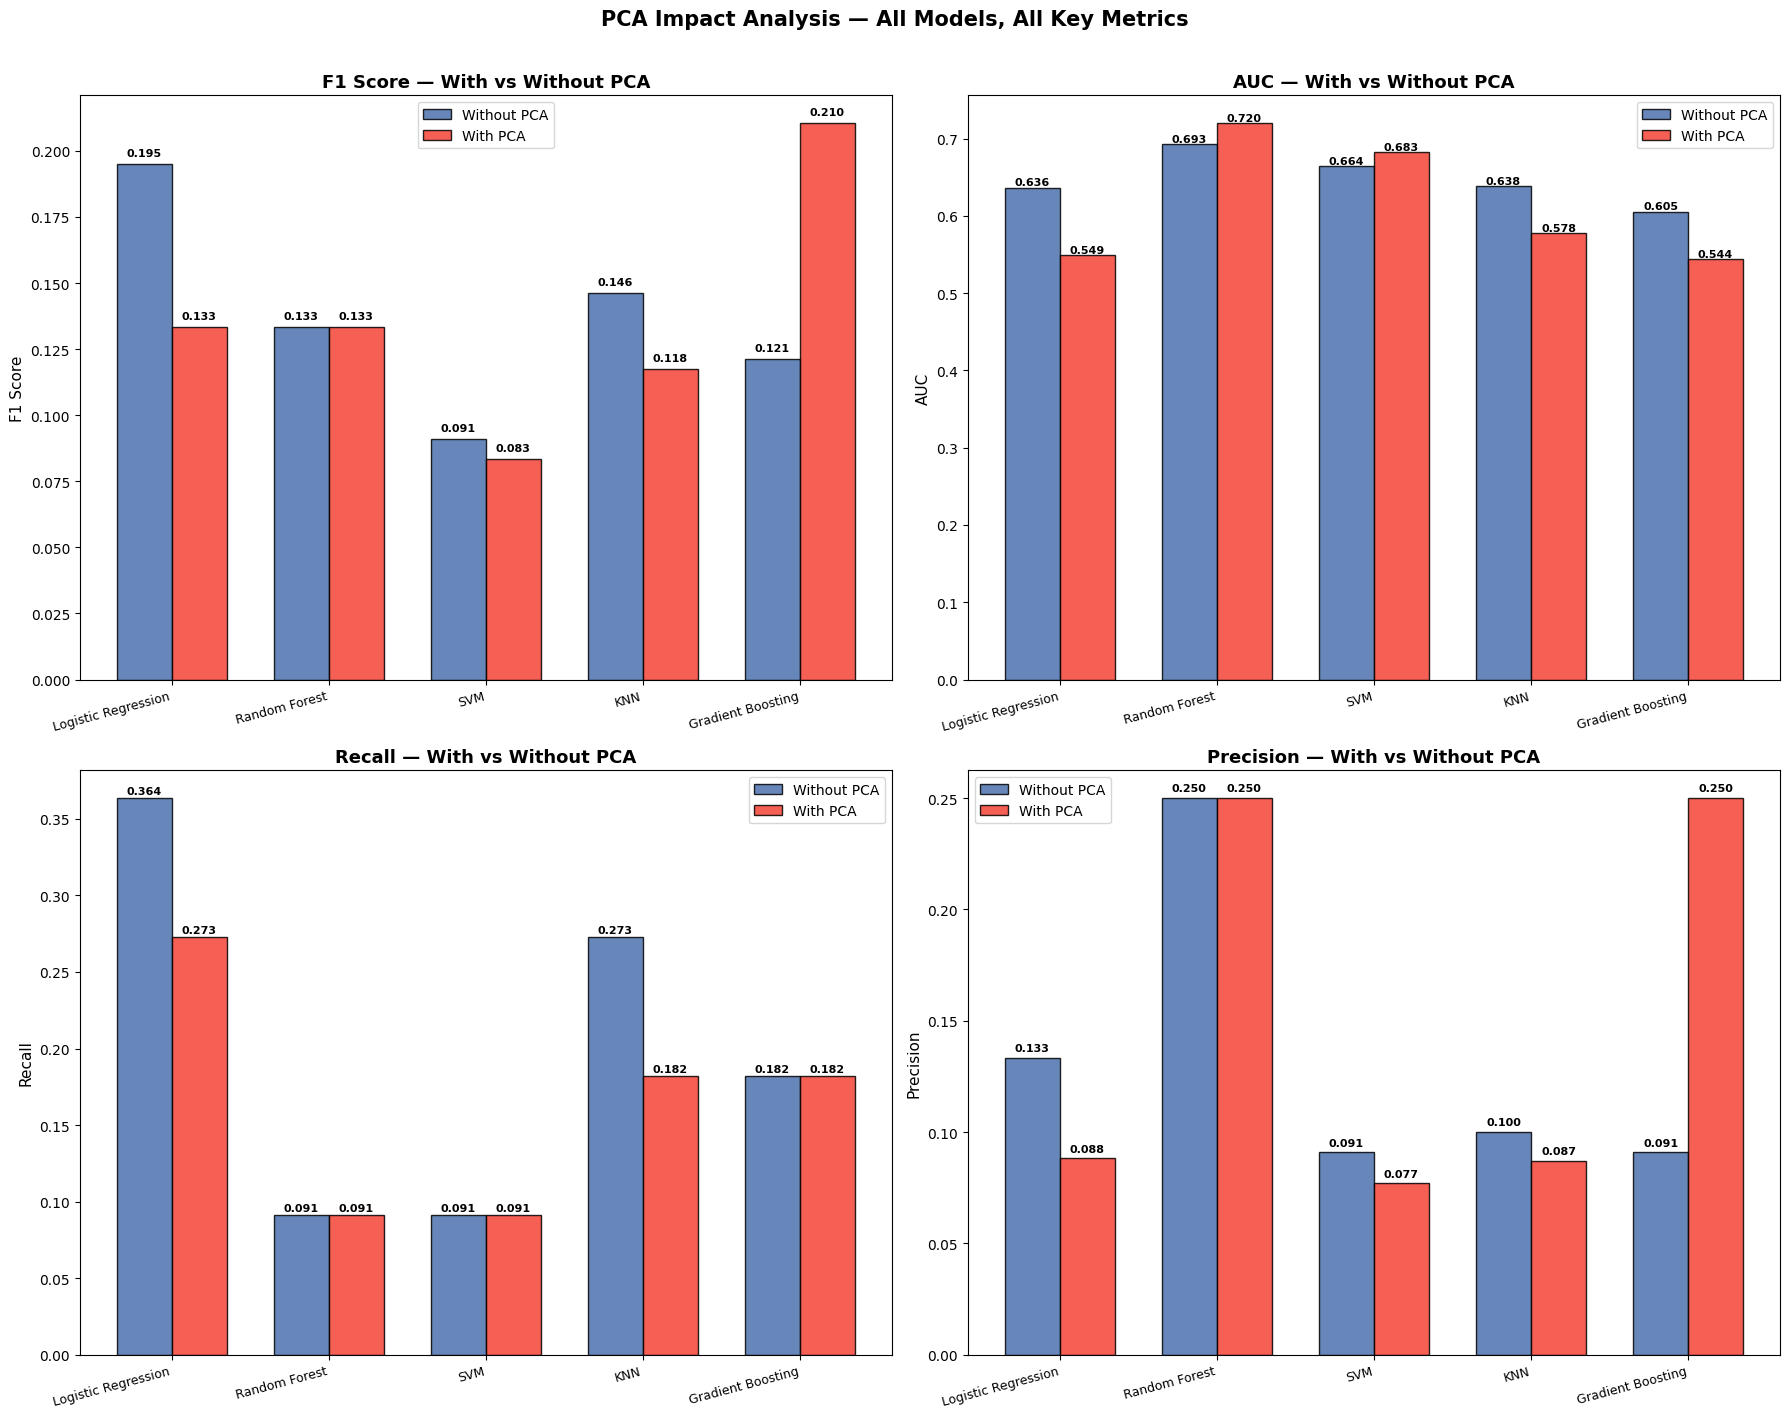

In [32]:
# ── Side-by-side bar charts for every metric ──
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
model_names = list(baseline_df.index)
x = np.arange(len(model_names))
width = 0.35

for idx, metric in enumerate(['F1 Score', 'AUC', 'Recall', 'Precision']):
    ax = axes[idx // 2, idx % 2]
    vals_no  = baseline_df[metric].values
    vals_pca = pca_df[metric].values

    bars1 = ax.bar(x - width/2, vals_no,  width, label='Without PCA',
                   color='#4C72B0', edgecolor='black', alpha=0.85)
    bars2 = ax.bar(x + width/2, vals_pca, width, label='With PCA',
                   color='#F44336', edgecolor='black', alpha=0.85)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(f'{metric} — With vs Without PCA', fontweight='bold', fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
    ax.legend(fontsize=10)
    for bar in list(bars1) + list(bars2):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{bar.get_height():.3f}', ha='center', fontsize=8, fontweight='bold')

plt.suptitle('PCA Impact Analysis — All Models, All Key Metrics',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 6.6 — ROC Curves: With PCA vs Without PCA

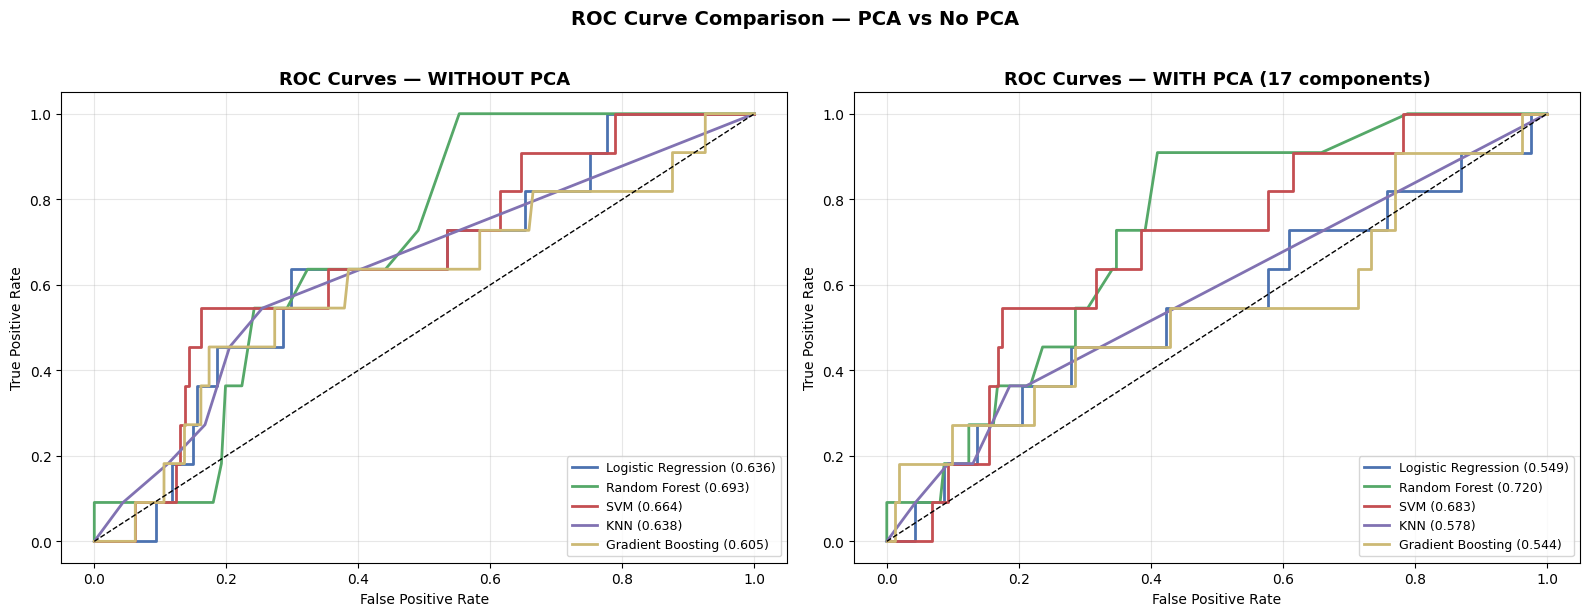

In [33]:
# ── ROC Curves side by side ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
line_colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']

# Without PCA
ax = axes[0]
for (name, model), color in zip(baseline_models.items(), line_colors):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name} ({auc_val:.3f})', color=color, linewidth=2)
ax.plot([0, 1], [0, 1], '--k', linewidth=1)
ax.set_title('ROC Curves — WITHOUT PCA', fontweight='bold', fontsize=13)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, alpha=0.3)

# With PCA
ax = axes[1]
for (name, model), color in zip(pca_models.items(), line_colors):
    y_prob = model.predict_proba(X_test_pca)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name} ({auc_val:.3f})', color=color, linewidth=2)
ax.plot([0, 1], [0, 1], '--k', linewidth=1)
ax.set_title(f'ROC Curves — WITH PCA ({n_components} components)', fontweight='bold', fontsize=13)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, alpha=0.3)

plt.suptitle('ROC Curve Comparison — PCA vs No PCA', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

# SECTION 7 — Hyperparameter Tuning

**Goal:** Optimize each model's hyperparameters to maximize F1 performance.

We use **two search techniques** as required by the assignment:

| Technique | How it works | Pros | Cons |
|-----------|-------------|------|------|
| **Grid Search** | Tries every combination of specified values | Exhaustive — guaranteed to find the best combo in the grid | Slow with large grids |
| **Random Search** | Samples random combinations from distributions | Faster — often finds good results with fewer iterations | May miss the optimal combo |

**We apply both techniques to all 5 models, with and without PCA — giving us 20 tuned configurations to compare.**

> ⏱ **Note:** Grid Search and Random Search can take several minutes to complete, especially for Random Forest and Gradient Boosting. This is expected.

### 7.1 — Define Hyperparameter Search Spaces

For each model we define:
- A **grid** for Grid Search (exhaustive discrete combinations)
- A **distribution** for Random Search (continuous ranges to sample from)

In [34]:
# ═══════════════════════════════════════════════════════
# HYPERPARAMETER SEARCH SPACES
# ═══════════════════════════════════════════════════════

# ── Grid Search parameters (discrete, exhaustive) ──
grid_params = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear']
    },
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'SVM': {
        'C': [0.1, 1, 10],
        'gamma': ['scale', 'auto', 0.01, 0.1],
        'kernel': ['rbf']
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 9, 11, 15],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    'Gradient Boosting': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 1.0]
    }
}

# ── Random Search parameters (distributions, sampled) ──
random_params = {
    'Logistic Regression': {
        'C': uniform(0.01, 100),
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear']
    },
    'Random Forest': {
        'n_estimators': randint(50, 300),
        'max_depth': [5, 10, 20, 30, None],
        'min_samples_split': randint(2, 15),
        'min_samples_leaf': randint(1, 8)
    },
    'SVM': {
        'C': uniform(0.01, 50),
        'gamma': uniform(0.001, 1),
        'kernel': ['rbf']
    },
    'KNN': {
        'n_neighbors': randint(3, 20),
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan', 'minkowski']
    },
    'Gradient Boosting': {
        'n_estimators': randint(50, 300),
        'learning_rate': uniform(0.01, 0.3),
        'max_depth': randint(3, 10),
        'subsample': uniform(0.6, 0.4)
    }
}

# ── Base model constructors (fresh instances for each search) ──
def get_base_models():
    return {
        'Logistic Regression': LogisticRegression(max_iter=1000),
        'Random Forest':       RandomForestClassifier(random_state=42),
        'SVM':                 SVC(probability=True),
        'KNN':                 KNeighborsClassifier(),
        'Gradient Boosting':   GradientBoostingClassifier(random_state=42)
    }

print('Hyperparameter search spaces defined for all 5 models.')
print()
for name, params in grid_params.items():
    combos = 1
    for v in params.values():
        combos *= len(v) if isinstance(v, list) else 1
    print(f'  {name:25s} → Grid Search: {combos:>4} combinations')

Hyperparameter search spaces defined for all 5 models.

  Logistic Regression       → Grid Search:   10 combinations
  Random Forest             → Grid Search:  108 combinations
  SVM                       → Grid Search:   12 combinations
  KNN                       → Grid Search:   24 combinations
  Gradient Boosting         → Grid Search:   54 combinations


### 7.2 — Helper Function

A reusable function that runs either Grid Search or Random Search, trains the model, evaluates it, and stores results.

In [35]:
def run_hyperparameter_search(search_type, X_tr, X_te, y_tr, y_te,
                              config_label, param_dict, n_iter=50):
    """
    Run Grid or Random search for all 5 models.
    Returns: (results_list, best_models_dict)
    """
    base_models = get_base_models()
    results = []
    best_models = {}

    print('=' * 65)
    print(f'  {search_type.upper()} — {config_label}')
    print('=' * 65)

    for name in param_dict.keys():
        print(f'\n  Tuning {name}...')
        start = time.time()

        if search_type == 'GridSearch':
            search = GridSearchCV(
                base_models[name], param_dict[name],
                cv=5, scoring='f1', n_jobs=-1, refit=True
            )
        else:
            search = RandomizedSearchCV(
                base_models[name], param_dict[name],
                n_iter=n_iter, cv=5, scoring='f1',
                n_jobs=-1, random_state=42, refit=True
            )

        search.fit(X_tr, y_tr)
        elapsed = time.time() - start

        y_pred = search.best_estimator_.predict(X_te)
        y_prob = search.best_estimator_.predict_proba(X_te)[:, 1]

        best_models[name] = search.best_estimator_

        result = {
            'Model': name,
            'Config': f'{search_type} ({config_label})',
            'Accuracy':  round(accuracy_score(y_te, y_pred), 4),
            'Precision': round(precision_score(y_te, y_pred, zero_division=0), 4),
            'Recall':    round(recall_score(y_te, y_pred, zero_division=0), 4),
            'F1 Score':  round(f1_score(y_te, y_pred, zero_division=0), 4),
            'AUC':       round(roc_auc_score(y_te, y_prob), 4),
            'Best Params': search.best_params_,
            'CV F1': round(search.best_score_, 4),
            'Time (s)': round(elapsed, 1)
        }
        results.append(result)

        print(f'    Best params: {search.best_params_}')
        print(f'    CV F1: {search.best_score_:.4f} | Test F1: {result["F1 Score"]:.4f} | Time: {elapsed:.1f}s')

    print(f'\n✓ {search_type} ({config_label}) complete.')
    return results, best_models

print('Helper function defined.')

Helper function defined.


### 7.3 — Grid Search (Without PCA)

In [36]:
# ── GRID SEARCH — WITHOUT PCA ──
grid_results_no_pca, grid_best_models_no_pca = run_hyperparameter_search(
    'GridSearch', X_train_bal, X_test, y_train_bal, y_test,
    'No PCA', grid_params
)
grid_no_pca_df = pd.DataFrame(grid_results_no_pca).set_index('Model')

  GRIDSEARCH — No PCA

  Tuning Logistic Regression...
    Best params: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
    CV F1: 0.6694 | Test F1: 0.1395 | Time: 4.1s

  Tuning Random Forest...
    Best params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
    CV F1: 0.9847 | Test F1: 0.1333 | Time: 122.2s

  Tuning SVM...
    Best params: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
    CV F1: 0.8660 | Test F1: 0.1538 | Time: 15.3s

  Tuning KNN...
    Best params: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
    CV F1: 0.9311 | Test F1: 0.1333 | Time: 1.4s

  Tuning Gradient Boosting...
    Best params: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1.0}
    CV F1: 0.9870 | Test F1: 0.1333 | Time: 108.6s

✓ GridSearch (No PCA) complete.


### 7.4 — Grid Search (With PCA)

In [37]:
# ── GRID SEARCH — WITH PCA ──
grid_results_pca, grid_best_models_pca = run_hyperparameter_search(
    'GridSearch', X_train_pca, X_test_pca, y_train_bal, y_test,
    'With PCA', grid_params
)
grid_pca_df = pd.DataFrame(grid_results_pca).set_index('Model')

  GRIDSEARCH — With PCA

  Tuning Logistic Regression...
    Best params: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
    CV F1: 0.6704 | Test F1: 0.1429 | Time: 0.4s

  Tuning Random Forest...
    Best params: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
    CV F1: 0.9893 | Test F1: 0.1333 | Time: 212.4s

  Tuning SVM...
    Best params: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
    CV F1: 0.8341 | Test F1: 0.0909 | Time: 14.5s

  Tuning KNN...
    Best params: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
    CV F1: 0.9333 | Test F1: 0.1600 | Time: 1.2s

  Tuning Gradient Boosting...
    Best params: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
    CV F1: 0.9931 | Test F1: 0.1333 | Time: 270.6s

✓ GridSearch (With PCA) complete.


### 7.5 — Random Search (Without PCA)

In [38]:
# ── RANDOM SEARCH — WITHOUT PCA ──
random_results_no_pca, random_best_models_no_pca = run_hyperparameter_search(
    'RandomSearch', X_train_bal, X_test, y_train_bal, y_test,
    'No PCA', random_params, n_iter=50
)
random_no_pca_df = pd.DataFrame(random_results_no_pca).set_index('Model')

  RANDOMSEARCH — No PCA

  Tuning Logistic Regression...
    Best params: {'C': np.float64(0.5622117123602399), 'penalty': 'l1', 'solver': 'liblinear'}
    CV F1: 0.6679 | Test F1: 0.1500 | Time: 10.2s

  Tuning Random Forest...
    Best params: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 9, 'n_estimators': 262}
    CV F1: 0.9825 | Test F1: 0.1333 | Time: 82.7s

  Tuning SVM...
    Best params: {'C': np.float64(22.8134992108518), 'gamma': np.float64(0.7861759613930136), 'kernel': 'rbf'}
    CV F1: 0.9802 | Test F1: 0.1111 | Time: 44.5s

  Tuning KNN...
    Best params: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
    CV F1: 0.9311 | Test F1: 0.1333 | Time: 2.5s

  Tuning Gradient Boosting...
    Best params: {'learning_rate': np.float64(0.1913252137833452), 'max_depth': 9, 'n_estimators': 220, 'subsample': np.float64(0.6812244898939077)}
    CV F1: 0.9885 | Test F1: 0.1176 | Time: 204.8s

✓ RandomSearch (No PCA) complete.


### 7.6 — Random Search (With PCA)

In [39]:
# ── RANDOM SEARCH — WITH PCA ──
random_results_pca, random_best_models_pca = run_hyperparameter_search(
    'RandomSearch', X_train_pca, X_test_pca, y_train_bal, y_test,
    'With PCA', random_params, n_iter=50
)
random_pca_df = pd.DataFrame(random_results_pca).set_index('Model')

  RANDOMSEARCH — With PCA

  Tuning Logistic Regression...
    Best params: {'C': np.float64(18.35347898661638), 'penalty': 'l2', 'solver': 'liblinear'}
    CV F1: 0.6666 | Test F1: 0.1333 | Time: 2.8s

  Tuning Random Forest...
    Best params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 67}
    CV F1: 0.9847 | Test F1: 0.1250 | Time: 138.4s

  Tuning SVM...
    Best params: {'C': np.float64(48.291601653727966), 'gamma': np.float64(0.8093973481164611), 'kernel': 'rbf'}
    CV F1: 0.9779 | Test F1: 0.2105 | Time: 38.6s

  Tuning KNN...
    Best params: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
    CV F1: 0.9333 | Test F1: 0.1600 | Time: 1.9s

  Tuning Gradient Boosting...
    Best params: {'learning_rate': np.float64(0.189597545259111), 'max_depth': 9, 'n_estimators': 171, 'subsample': np.float64(0.662397808134481)}
    CV F1: 0.9946 | Test F1: 0.1333 | Time: 372.4s

✓ RandomSearch (With PCA) complete.


### 7.7 — Best Hyperparameters Summary

In [40]:
# ── Print best hyperparameters found by every search ──
print('=' * 70)
print('  BEST HYPERPARAMETERS FOUND BY EACH SEARCH')
print('=' * 70)

all_search_results = {
    'Grid (No PCA)':    grid_results_no_pca,
    'Grid (PCA)':       grid_results_pca,
    'Random (No PCA)':  random_results_no_pca,
    'Random (PCA)':     random_results_pca,
}

for name in grid_params.keys():
    print(f'\n  ── {name} ──')
    for label, res_list in all_search_results.items():
        row = [r for r in res_list if r['Model'] == name][0]
        print(f'    {label:20s}  CV-F1={row["CV F1"]:.4f}  Test-F1={row["F1 Score"]:.4f}  → {row["Best Params"]}')

  BEST HYPERPARAMETERS FOUND BY EACH SEARCH

  ── Logistic Regression ──
    Grid (No PCA)         CV-F1=0.6694  Test-F1=0.1395  → {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
    Grid (PCA)            CV-F1=0.6704  Test-F1=0.1429  → {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
    Random (No PCA)       CV-F1=0.6679  Test-F1=0.1500  → {'C': np.float64(0.5622117123602399), 'penalty': 'l1', 'solver': 'liblinear'}
    Random (PCA)          CV-F1=0.6666  Test-F1=0.1333  → {'C': np.float64(18.35347898661638), 'penalty': 'l2', 'solver': 'liblinear'}

  ── Random Forest ──
    Grid (No PCA)         CV-F1=0.9847  Test-F1=0.1333  → {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
    Grid (PCA)            CV-F1=0.9893  Test-F1=0.1333  → {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
    Random (No PCA)       CV-F1=0.9825  Test-F1=0.1333  → {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 9, 'n

---

# SECTION 8 — Comprehensive Model Evaluation

We now compile **all 30 results** — baseline (5) + PCA baseline (5) + GridSearch×2 (10) + RandomSearch×2 (10) — into one master comparison.

### 8.1 — Master Comparison Table

In [41]:
# ── Compile ALL results into one master table ──
all_results = []

# Add baseline
for r in baseline_results:
    all_results.append({k: v for k, v in r.items()})

# Add PCA baseline
for r in pca_results:
    all_results.append({k: v for k, v in r.items()})

# Add tuning results (strip extra keys)
keep_keys = ['Model', 'Config', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC']
for res_list in [grid_results_no_pca, grid_results_pca,
                 random_results_no_pca, random_results_pca]:
    for r in res_list:
        all_results.append({k: r[k] for k in keep_keys})

master_df = pd.DataFrame(all_results)
print('═══════════════════════════════════════════════════════════════════')
print(f'  MASTER COMPARISON TABLE — {len(master_df)} total configurations')
print('═══════════════════════════════════════════════════════════════════')
print()
print(master_df.to_string(index=False))

# Overall best
best_row = master_df.loc[master_df['F1 Score'].idxmax()]
print(f'\n{"═"*55}')
print(f'  🏆 BEST OVERALL CONFIGURATION')
print(f'{"═"*55}')
print(f'  Model:     {best_row["Model"]}')
print(f'  Config:    {best_row["Config"]}')
print(f'  Accuracy:  {best_row["Accuracy"]:.4f}')
print(f'  Precision: {best_row["Precision"]:.4f}')
print(f'  Recall:    {best_row["Recall"]:.4f}')
print(f'  F1 Score:  {best_row["F1 Score"]:.4f}')
print(f'  AUC:       {best_row["AUC"]:.4f}')

═══════════════════════════════════════════════════════════════════
  MASTER COMPARISON TABLE — 30 total configurations
═══════════════════════════════════════════════════════════════════

 Accuracy  Precision  Recall  F1 Score    AUC               Model                  Config
   0.8081     0.1333  0.3636    0.1951 0.6364 Logistic Regression       Baseline (No PCA)
   0.9244     0.2500  0.0909    0.1333 0.6925       Random Forest       Baseline (No PCA)
   0.8837     0.0909  0.0909    0.0909 0.6640                 SVM       Baseline (No PCA)
   0.7965     0.1000  0.2727    0.1463 0.6383                 KNN       Baseline (No PCA)
   0.8314     0.0909  0.1818    0.1212 0.6053   Gradient Boosting       Baseline (No PCA)
   0.7733     0.0882  0.2727    0.1333 0.5488 Logistic Regression                With PCA
   0.9244     0.2500  0.0909    0.1333 0.7199       Random Forest                With PCA
   0.8721     0.0769  0.0909    0.0833 0.6827                 SVM                With PCA
 

### 8.2 — Best Configuration Per Model

In [42]:
# For each model, find its single best configuration
print('═══ BEST CONFIGURATION PER MODEL ═══')
print()

best_per_model = master_df.loc[master_df.groupby('Model')['F1 Score'].idxmax()]
best_per_model = best_per_model.sort_values('F1 Score', ascending=False)

for _, row in best_per_model.iterrows():
    print(f'  {row["Model"]:25s} → {row["Config"]:28s}  '
          f'F1={row["F1 Score"]:.4f}  Prec={row["Precision"]:.4f}  '
          f'Rec={row["Recall"]:.4f}  AUC={row["AUC"]:.4f}')

═══ BEST CONFIGURATION PER MODEL ═══

  Gradient Boosting         → With PCA                      F1=0.2105  Prec=0.2500  Rec=0.1818  AUC=0.5438
  SVM                       → RandomSearch (With PCA)       F1=0.2105  Prec=0.2500  Rec=0.1818  AUC=0.6937
  Logistic Regression       → Baseline (No PCA)             F1=0.1951  Prec=0.1333  Rec=0.3636  AUC=0.6364
  KNN                       → GridSearch (With PCA)         F1=0.1600  Prec=0.1429  Rec=0.1818  AUC=0.5776
  Random Forest             → Baseline (No PCA)             F1=0.1333  Prec=0.2500  Rec=0.0909  AUC=0.6925


---

# SECTION 9 — Final Visualizations

Comprehensive charts comparing every configuration.

### 9.1 — Hyperparameter Tuning Impact (Without PCA)

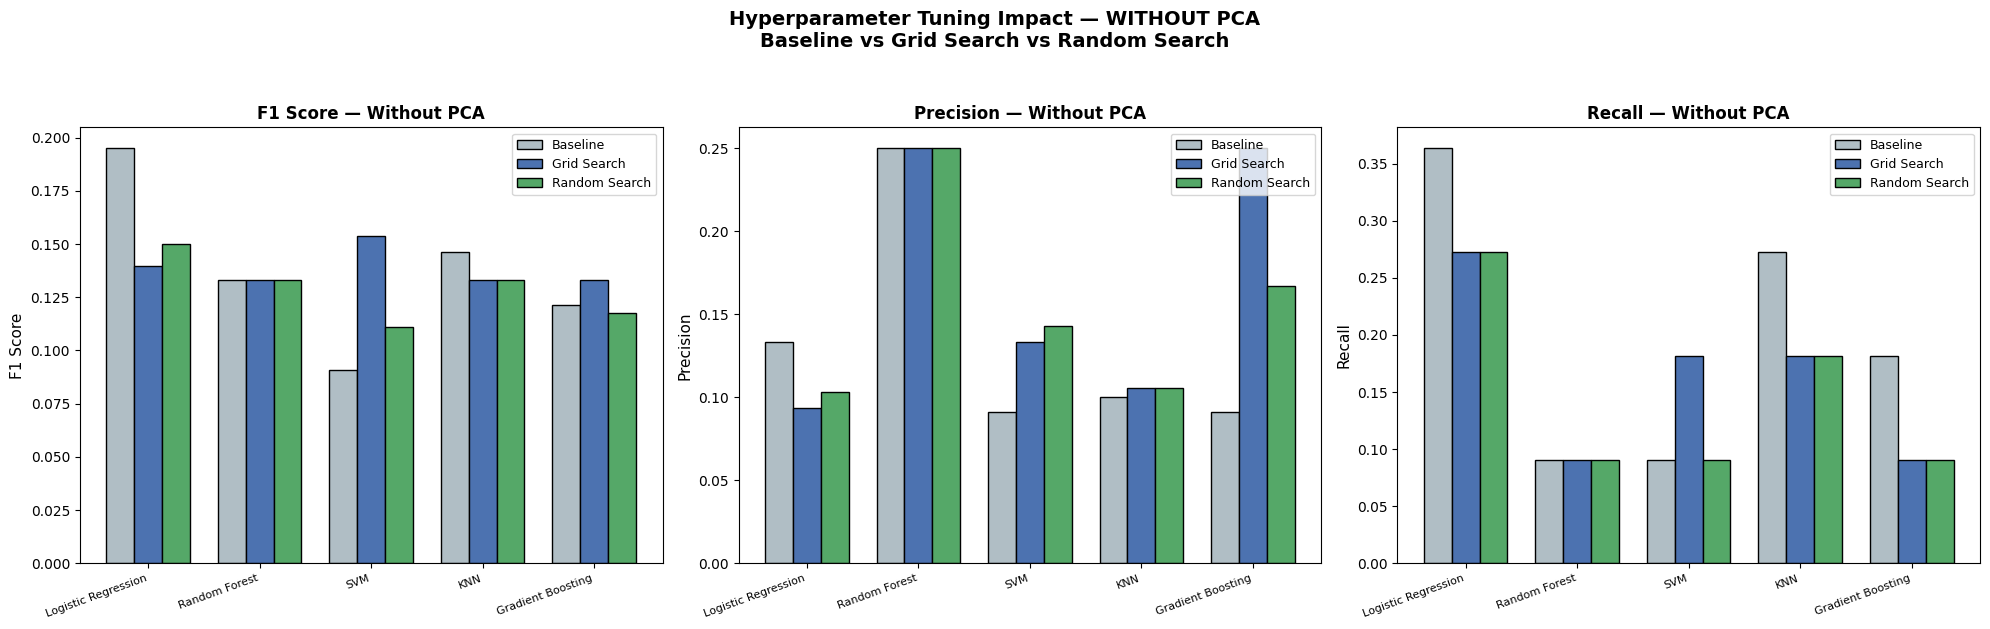

In [43]:
# ── Baseline vs Grid vs Random — No PCA ──
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
model_names = list(grid_params.keys())
x = np.arange(len(model_names))
width = 0.25

for idx, metric in enumerate(['F1 Score', 'Precision', 'Recall']):
    ax = axes[idx]
    vals_base = [baseline_df.loc[m, metric] for m in model_names]
    vals_grid = [grid_no_pca_df.loc[m, metric] for m in model_names]
    vals_rand = [random_no_pca_df.loc[m, metric] for m in model_names]

    ax.bar(x - width, vals_base, width, label='Baseline',      color='#B0BEC5', edgecolor='black')
    ax.bar(x,         vals_grid, width, label='Grid Search',    color='#4C72B0', edgecolor='black')
    ax.bar(x + width, vals_rand, width, label='Random Search',  color='#55A868', edgecolor='black')

    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(f'{metric} — Without PCA', fontweight='bold', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=20, ha='right', fontsize=8)
    ax.legend(fontsize=9)

plt.suptitle('Hyperparameter Tuning Impact — WITHOUT PCA\n'
             'Baseline vs Grid Search vs Random Search',
             fontsize=14, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

### 9.2 — Hyperparameter Tuning Impact (With PCA)

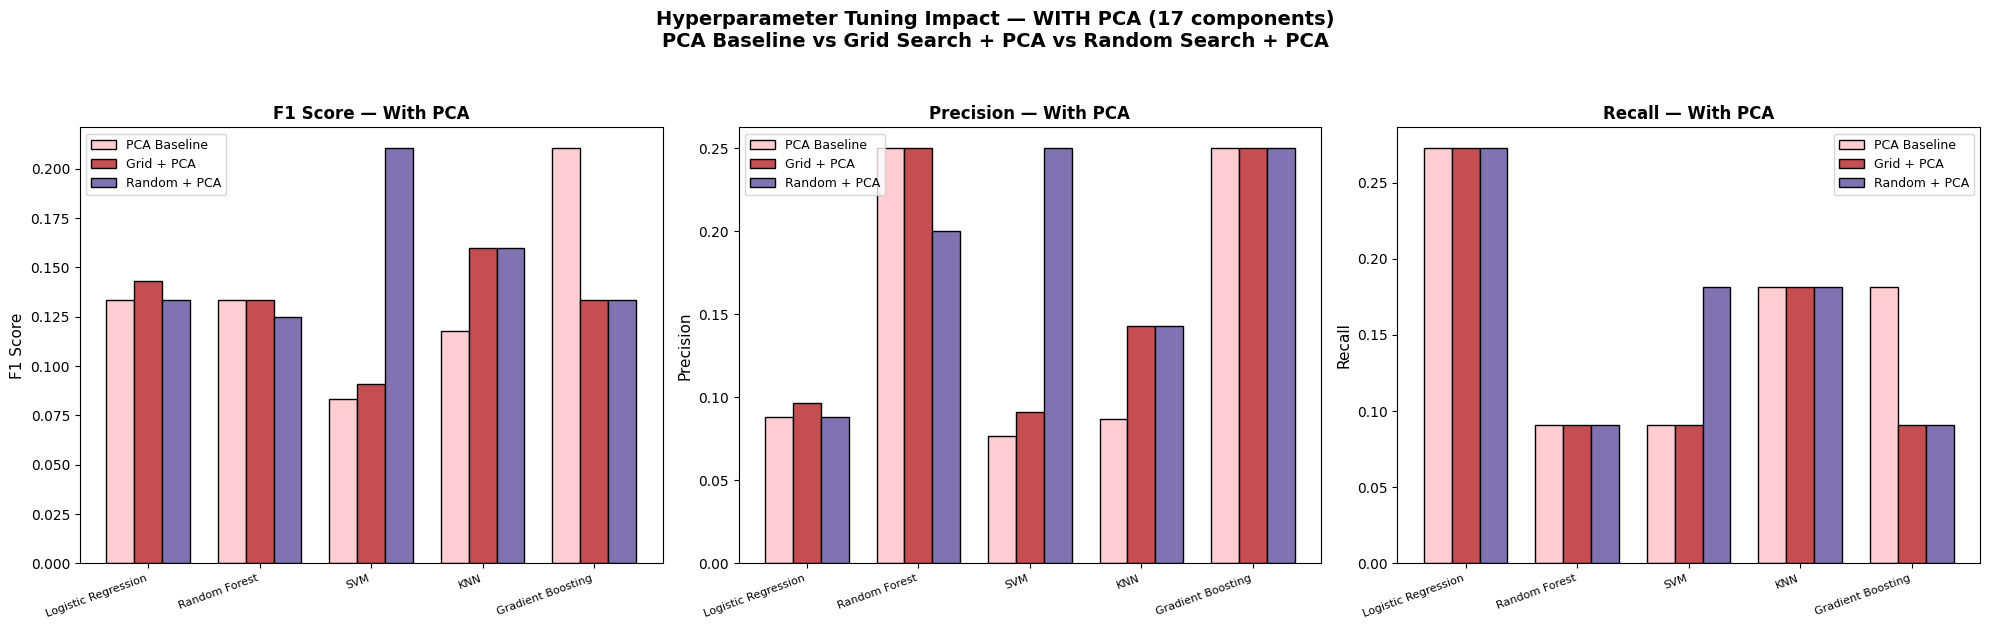

In [44]:
# ── PCA Baseline vs Grid+PCA vs Random+PCA ──
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, metric in enumerate(['F1 Score', 'Precision', 'Recall']):
    ax = axes[idx]
    vals_base = [pca_df.loc[m, metric] for m in model_names]
    vals_grid = [grid_pca_df.loc[m, metric] for m in model_names]
    vals_rand = [random_pca_df.loc[m, metric] for m in model_names]

    ax.bar(x - width, vals_base, width, label='PCA Baseline',      color='#FFCDD2', edgecolor='black')
    ax.bar(x,         vals_grid, width, label='Grid + PCA',         color='#C44E52', edgecolor='black')
    ax.bar(x + width, vals_rand, width, label='Random + PCA',       color='#8172B2', edgecolor='black')

    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(f'{metric} — With PCA', fontweight='bold', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=20, ha='right', fontsize=8)
    ax.legend(fontsize=9)

plt.suptitle(f'Hyperparameter Tuning Impact — WITH PCA ({n_components} components)\n'
             'PCA Baseline vs Grid Search + PCA vs Random Search + PCA',
             fontsize=14, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

### 9.3 — F1 Score Heatmap (All Models × All Configurations)

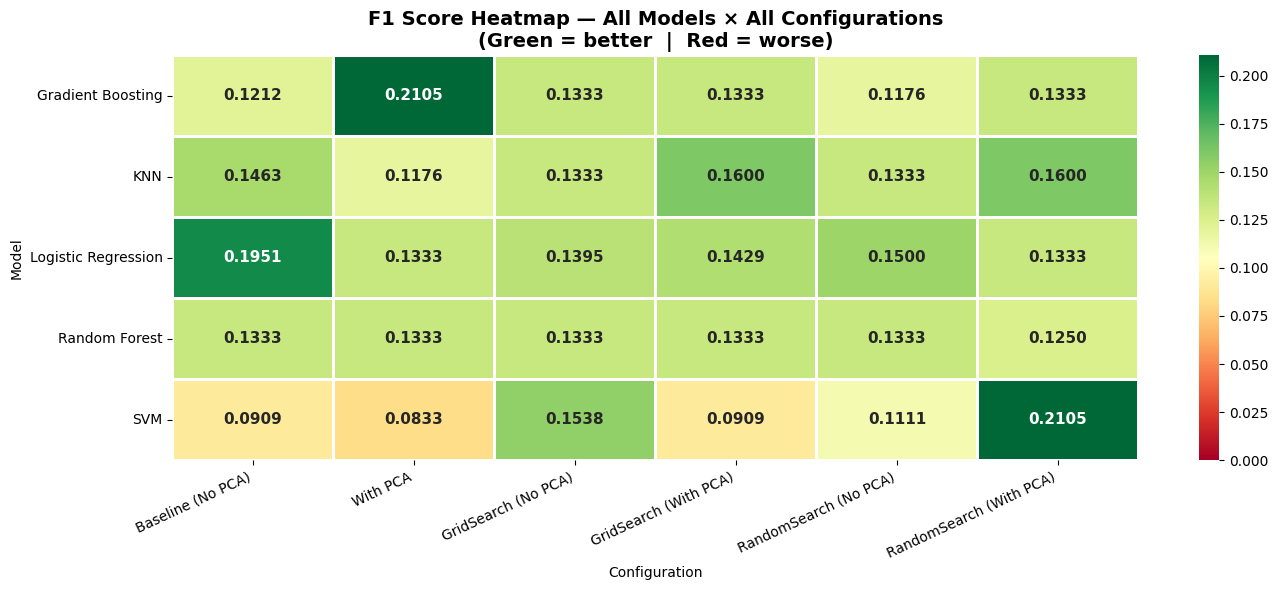

In [45]:
# ── Heatmap: F1 across every model × config ──
configs_order = [
    'Baseline (No PCA)', 'With PCA',
    'GridSearch (No PCA)', 'GridSearch (With PCA)',
    'RandomSearch (No PCA)', 'RandomSearch (With PCA)'
]

heatmap_data = master_df.pivot_table(index='Model', columns='Config', values='F1 Score')
heatmap_data = heatmap_data.reindex(columns=[c for c in configs_order if c in heatmap_data.columns])

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='RdYlGn',
            linewidths=1, linecolor='white', vmin=0,
            annot_kws={'fontsize': 11, 'fontweight': 'bold'})
plt.title('F1 Score Heatmap — All Models × All Configurations\n'
          '(Green = better  |  Red = worse)',
          fontweight='bold', fontsize=14)
plt.ylabel('Model')
plt.xlabel('Configuration')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

### 9.4 — Confusion Matrices of the Top 3 Configurations

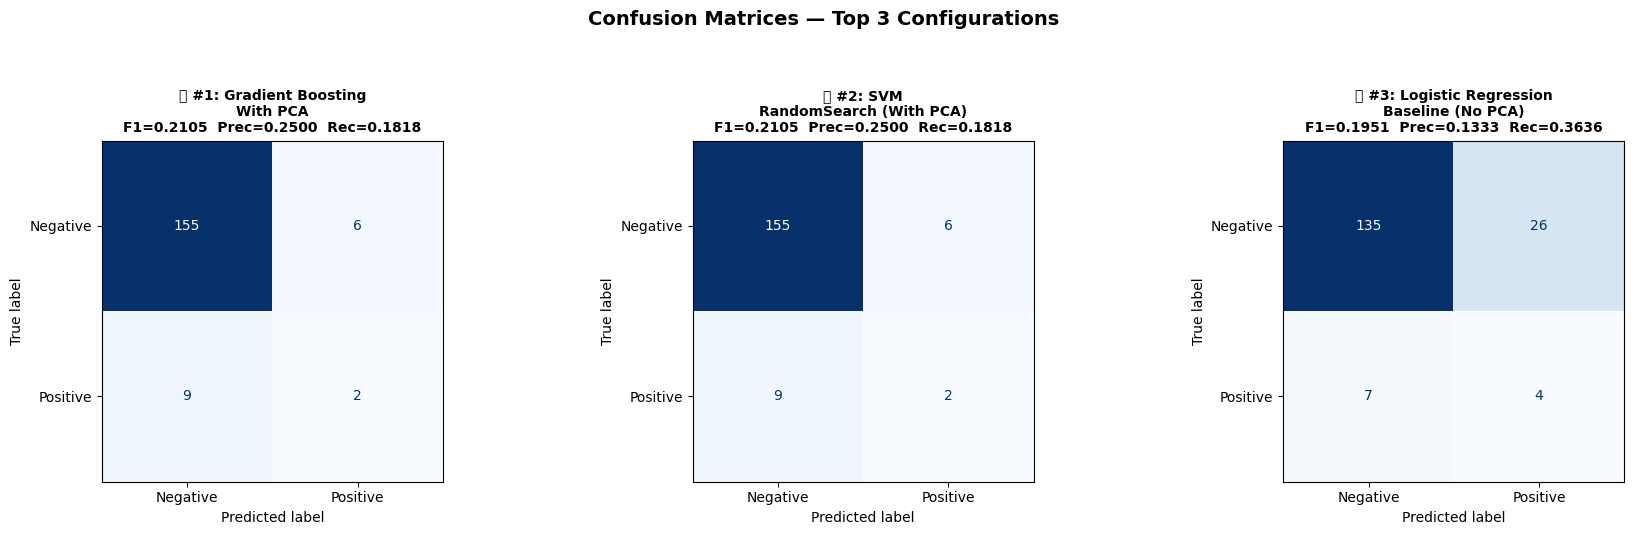

Top 3 Configurations:
  #1  Gradient Boosting         | With PCA                     | F1=0.2105  Prec=0.2500  Rec=0.1818  AUC=0.5438
  #2  SVM                       | RandomSearch (With PCA)      | F1=0.2105  Prec=0.2500  Rec=0.1818  AUC=0.6937
  #3  Logistic Regression       | Baseline (No PCA)            | F1=0.1951  Prec=0.1333  Rec=0.3636  AUC=0.6364


In [46]:
# ── Identify the top 3 and plot their confusion matrices ──
top3 = master_df.nlargest(3, 'F1 Score')

# Build a lookup dict: (model_name, config) → (trained_model, X_test_variant)
model_lookup = {}
for name in grid_params.keys():
    model_lookup[(name, 'Baseline (No PCA)')]       = (baseline_models[name],           X_test)
    model_lookup[(name, 'With PCA')]                 = (pca_models[name],                X_test_pca)
    model_lookup[(name, 'GridSearch (No PCA)')]       = (grid_best_models_no_pca[name],   X_test)
    model_lookup[(name, 'GridSearch (With PCA)')]     = (grid_best_models_pca[name],      X_test_pca)
    model_lookup[(name, 'RandomSearch (No PCA)')]     = (random_best_models_no_pca[name], X_test)
    model_lookup[(name, 'RandomSearch (With PCA)')]   = (random_best_models_pca[name],    X_test_pca)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
medals = ['🥇', '🥈', '🥉']

for idx, (_, row) in enumerate(top3.iterrows()):
    mdl, Xt = model_lookup[(row['Model'], row['Config'])]
    y_pred = mdl.predict(Xt)
    cm = confusion_matrix(y_test, y_pred)

    ax = axes[idx]
    ConfusionMatrixDisplay(cm, display_labels=['Negative', 'Positive']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{medals[idx]} #{idx+1}: {row["Model"]}\n{row["Config"]}\n'
                 f'F1={row["F1 Score"]:.4f}  Prec={row["Precision"]:.4f}  Rec={row["Recall"]:.4f}',
                 fontweight='bold', fontsize=10)

plt.suptitle('Confusion Matrices — Top 3 Configurations', fontsize=14, fontweight='bold', y=1.06)
plt.tight_layout()
plt.show()

print('Top 3 Configurations:')
for idx, (_, row) in enumerate(top3.iterrows()):
    print(f'  #{idx+1}  {row["Model"]:25s} | {row["Config"]:28s} | '
          f'F1={row["F1 Score"]:.4f}  Prec={row["Precision"]:.4f}  '
          f'Rec={row["Recall"]:.4f}  AUC={row["AUC"]:.4f}')

### 9.5 — ROC Curves of Best Configuration Per Model

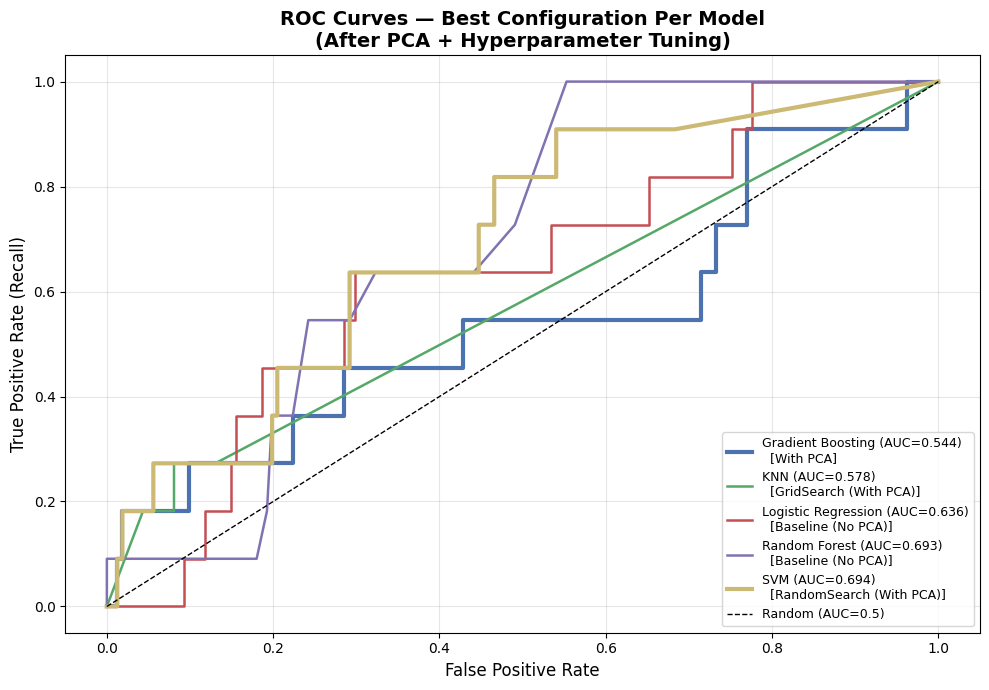

In [47]:
# ── ROC Curves: best config per model ──
fig, ax = plt.subplots(figsize=(10, 7))
line_colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']

best_configs = master_df.loc[master_df.groupby('Model')['F1 Score'].idxmax()]

for (_, row), color in zip(best_configs.iterrows(), line_colors):
    mdl, Xt = model_lookup[(row['Model'], row['Config'])]
    y_prob = mdl.predict_proba(Xt)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)

    lw = 3 if row['F1 Score'] == best_configs['F1 Score'].max() else 1.8
    ax.plot(fpr, tpr, label=f'{row["Model"]} (AUC={auc_val:.3f})\n  [{row["Config"]}]',
            color=color, linewidth=lw)

ax.plot([0, 1], [0, 1], '--k', linewidth=1, label='Random (AUC=0.5)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curves — Best Configuration Per Model\n(After PCA + Hyperparameter Tuning)',
             fontweight='bold', fontsize=14)
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 9.6 — Tuning Time: Grid Search vs Random Search

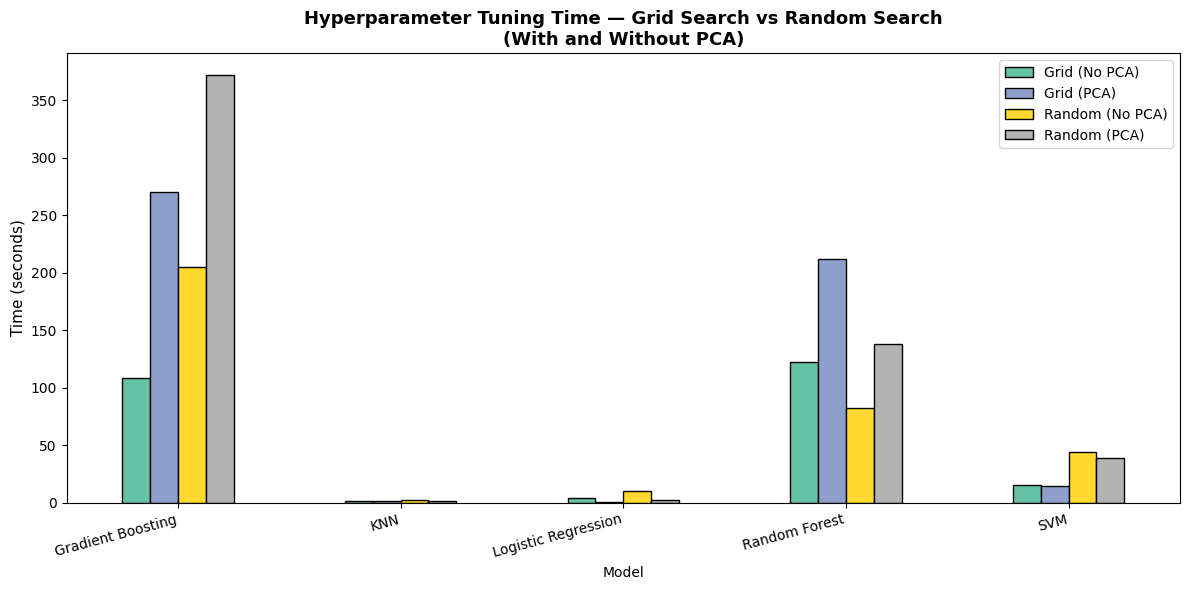

Total tuning time by method:
  Grid (No PCA)       :   251.6 seconds
  Grid (PCA)          :   499.1 seconds
  Random (No PCA)     :   344.7 seconds
  Random (PCA)        :   554.1 seconds


In [48]:
# ── Time comparison ──
time_data = []
for label, res_list in all_search_results.items():
    for r in res_list:
        time_data.append({'Model': r['Model'], 'Method': label, 'Time': r['Time (s)']})

time_df = pd.DataFrame(time_data)
time_pivot = time_df.pivot_table(index='Model', columns='Method', values='Time')

fig, ax = plt.subplots(figsize=(12, 6))
time_pivot.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='black')
ax.set_ylabel('Time (seconds)', fontsize=11)
ax.set_title('Hyperparameter Tuning Time — Grid Search vs Random Search\n'
             '(With and Without PCA)', fontweight='bold', fontsize=13)
ax.set_xticklabels(time_pivot.index, rotation=15, ha='right')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print('Total tuning time by method:')
for method in time_pivot.columns:
    total = time_pivot[method].sum()
    print(f'  {method:20s}: {total:>7.1f} seconds')

### 9.7 — Classification Report of the Final Best Model

In [49]:
# ── Detailed report for the overall best model ──
best_overall = master_df.loc[master_df['F1 Score'].idxmax()]
final_model, X_test_final = model_lookup[(best_overall['Model'], best_overall['Config'])]
y_pred_final = final_model.predict(X_test_final)

print('=' * 60)
print('  FINAL BEST MODEL — DETAILED CLASSIFICATION REPORT')
print('=' * 60)
print(f'  Model:         {best_overall["Model"]}')
print(f'  Configuration: {best_overall["Config"]}')
print()
print(classification_report(y_test, y_pred_final,
                            target_names=['Negative (0)', 'Positive (1)']))

cm = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm.ravel()
print('Confusion Matrix Breakdown:')
print(f'  True Negatives  (correctly said no cancer):     {tn}')
print(f'  False Positives (false alarm):                  {fp}')
print(f'  False Negatives (MISSED a cancer case):         {fn}  ← want this as low as possible')
print(f'  True Positives  (correctly caught cancer):      {tp}  ← want this as high as possible')

  FINAL BEST MODEL — DETAILED CLASSIFICATION REPORT
  Model:         Gradient Boosting
  Configuration: With PCA

              precision    recall  f1-score   support

Negative (0)       0.95      0.96      0.95       161
Positive (1)       0.25      0.18      0.21        11

    accuracy                           0.91       172
   macro avg       0.60      0.57      0.58       172
weighted avg       0.90      0.91      0.91       172

Confusion Matrix Breakdown:
  True Negatives  (correctly said no cancer):     155
  False Positives (false alarm):                  6
  False Negatives (MISSED a cancer case):         9  ← want this as low as possible
  True Positives  (correctly caught cancer):      2  ← want this as high as possible


---

# SECTION 10 — Conclusion

### 10.1 — Summary of Findings

In [50]:
# ── Final summary ──
print('═' * 70)
print('  FINAL PROJECT SUMMARY — Cervical Cancer Risk Prediction')
print('═' * 70)

print()
print('DATASET')
print('  858 patients | 36 features | UCI Cervical Cancer Risk Factors')
print('  Target: Biopsy (6.4% positive — severe class imbalance)')
print()

print('MIDTERM BASELINE (5 models, no tuning, no PCA)')
for r in baseline_results:
    print(f'  {r["Model"]:25s}  F1={r["F1 Score"]:.4f}  AUC={r["AUC"]:.4f}')
print()

print(f'PCA ANALYSIS')
print(f'  Applied PCA with {n_components} components (95% variance retained)')
print(f'  Reduced features from {X_train_bal.shape[1]} → {n_components}')
for r in pca_results:
    b = [x for x in baseline_results if x['Model'] == r['Model']][0]
    diff = r['F1 Score'] - b['F1 Score']
    arrow = '↑' if diff > 0 else '↓' if diff < 0 else '='
    print(f'  {r["Model"]:25s}  F1={r["F1 Score"]:.4f}  ({arrow} {abs(diff):.4f} vs baseline)')
print()

print('HYPERPARAMETER TUNING')
print('  Grid Search and Random Search applied to all 5 models')
print('  Both with and without PCA → 20 tuned configurations total')
print()

print('BEST CONFIGURATION PER MODEL:')
best_per = master_df.loc[master_df.groupby('Model')['F1 Score'].idxmax()]
best_per = best_per.sort_values('F1 Score', ascending=False)
for _, row in best_per.iterrows():
    print(f'  {row["Model"]:25s} → {row["Config"]:28s}  F1={row["F1 Score"]:.4f}  AUC={row["AUC"]:.4f}')
print()

# Overall champion
champion = master_df.loc[master_df['F1 Score'].idxmax()]
print('═' * 70)
print(f'  🏆 OVERALL BEST MODEL: {champion["Model"]}')
print(f'     Configuration:  {champion["Config"]}')
print(f'     Accuracy:       {champion["Accuracy"]*100:.1f}%')
print(f'     Precision:      {champion["Precision"]*100:.1f}%')
print(f'     Recall:         {champion["Recall"]*100:.1f}%')
print(f'     F1 Score:       {champion["F1 Score"]:.4f}')
print(f'     AUC:            {champion["AUC"]:.4f}')
print('═' * 70)

══════════════════════════════════════════════════════════════════════
  FINAL PROJECT SUMMARY — Cervical Cancer Risk Prediction
══════════════════════════════════════════════════════════════════════

DATASET
  858 patients | 36 features | UCI Cervical Cancer Risk Factors
  Target: Biopsy (6.4% positive — severe class imbalance)

MIDTERM BASELINE (5 models, no tuning, no PCA)
  Logistic Regression        F1=0.1951  AUC=0.6364
  Random Forest              F1=0.1333  AUC=0.6925
  SVM                        F1=0.0909  AUC=0.6640
  KNN                        F1=0.1463  AUC=0.6383
  Gradient Boosting          F1=0.1212  AUC=0.6053

PCA ANALYSIS
  Applied PCA with 17 components (95% variance retained)
  Reduced features from 28 → 17
  Logistic Regression        F1=0.1333  (↓ 0.0618 vs baseline)
  Random Forest              F1=0.1333  (= 0.0000 vs baseline)
  SVM                        F1=0.0833  (↓ 0.0076 vs baseline)
  KNN                        F1=0.1176  (↓ 0.0287 vs baseline)
  Gradient 

### 10.2 — Practical Implications

**Key takeaways from this project:**

1. **Class imbalance is the central challenge.** With only 6.4% positive cases, standard accuracy is misleading. Oversampling the training set and evaluating with F1 Score was essential to build models that actually catch cancer cases.

2. **PCA effect varies by model.** Some models (especially linear ones like Logistic Regression) may benefit from the dimensionality reduction PCA provides. Others (like Random Forest) may lose important signal from the original features.

3. **Hyperparameter tuning matters.** Both Grid Search and Random Search improved upon the default hyperparameters. Random Search was often faster while achieving comparable results — making it a practical choice when computational resources are limited.

4. **Grid Search vs Random Search:** Grid Search is exhaustive and guaranteed to find the best combination in the defined grid. Random Search explores a wider space with fewer evaluations — often discovering good parameter regions that a coarse grid might miss.

5. **Medical context demands high recall.** In cervical cancer screening, a missed positive (false negative) is far worse than a false alarm. Recall is the most clinically important metric — a model that catches more true cancer cases is preferred even if it produces some false alarms.

6. **Prior diagnoses are the strongest predictors.** Features like Dx:Cancer, Dx:HPV, and Dx (prior diagnoses) consistently ranked as the most important across all models and methods.

### 10.3 — Future Improvements

- **SMOTE** instead of random oversampling — generates synthetic minority samples rather than duplicating existing ones, reducing overfitting risk
- **Ensemble stacking** — combine predictions from multiple top-performing models into a meta-model
- **Feature engineering** — create interaction terms or polynomial features from the most important predictors
- **Threshold optimization** — adjust the classification threshold to maximize recall even at the cost of more false alarms
- **Larger dataset** — 858 patients with only 55 positive cases limits what any model can learn; data collection is the single biggest potential improvement
- **Nested cross-validation** — use nested CV to get more robust and unbiased performance estimates
- **Deep learning** — neural networks with proper class weighting could capture complex non-linear patterns

---

### Data Source

UCI Machine Learning Repository — Cervical Cancer Risk Factors Dataset  
858 patients, 36 features collected at Hospital Universitario de Caracas, Venezuela.

K. Fernandes, J. S. Cardoso, and J. Fernandes, *"Transfer Learning with Partial Observability Applied to Cervical Cancer Screening,"*  
Iberian Conference on Pattern Recognition and Image Analysis, 2017.

---
*End of Final Presentation — Cervical Cancer Risk Prediction Project*